# Student Depression Prediction
### SENG 352 Notebook-First Final Delivery

---

A complete ML pipeline exploring the drivers of student depression — from data quality to explainable predictions and interactive demo.

## Notebook Roadmap (11 Sections)
1. Problem, aim, and disclaimer
2. Data Quality Assessment (DQA)
3. Exploratory Data Analysis (EDA)
4. Preprocessing + Feature Engineering
5. Modeling + Hyperparameter Tuning
6. Test Evaluation + Error Analysis
7. Explainability (SHAP + LIME-ready)
8. Fairness + Statistical Significance + Confidence Interval
9. Model Card Summary + Ethics + Limitations
10. Gradio Interactive Demo
11. Final Results + Checklist Evidence Matrix

> This notebook is for educational analysis and early-warning discussion only. It is **not** a clinical diagnostic tool.

In [1]:
!pip install -q missingno shap plotly xgboost lightgbm imbalanced-learn gradio mlflow optuna lime
print('Colab packages installed.')


Colab packages installed.


In [2]:
import os, pickle, time, warnings, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.stats import pointbiserialr
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    precision_recall_curve, roc_auc_score, roc_curve,
    f1_score, average_precision_score,
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_validate,
    train_test_split, learning_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

try:
    from xgboost import XGBClassifier; HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier; HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import shap; HAS_SHAP = True
except ImportError:
    HAS_SHAP = False; print('SHAP not available')

warnings.filterwarnings('ignore')
%matplotlib inline

# ── THEME ENGINE ──────────────────────────────────────────────────────────────
THEME = {
    'bg':        '#F5FBDA',
    'secondary': '#D9EFBD',
    'primary':   '#B9D175',
    'accent':    '#A33E79',
    'dark':      '#450C3F',
}
C_NO  = THEME['primary']
C_YES = THEME['accent']
PALETTE = {0: C_NO, 1: C_YES}
PALETTE_LIST = [C_NO, C_YES]

mpl.rcParams.update({
    'figure.facecolor':  THEME['bg'],
    'axes.facecolor':    THEME['bg'],
    'axes.edgecolor':    THEME['secondary'],
    'axes.linewidth':    0.8,
    'text.color':        THEME['dark'],
    'axes.labelcolor':   THEME['dark'],
    'xtick.color':       THEME['dark'],
    'ytick.color':       THEME['dark'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'axes.grid.axis':    'y',
    'grid.color':        THEME['secondary'],
    'grid.linewidth':    0.5,
    'grid.alpha':        0.7,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     10,
    'figure.dpi':        120,
})

custom_cmap = LinearSegmentedColormap.from_list(
    'premium', [THEME['bg'], THEME['primary'], THEME['accent'], THEME['dark']]
)
div_cmap = LinearSegmentedColormap.from_list(
    'diverging', [THEME['accent'], THEME['bg'], THEME['primary']]
)

PL = dict(
    paper_bgcolor=THEME['bg'],
    plot_bgcolor=THEME['bg'],
    font=dict(color=THEME['dark'], family='Arial, sans-serif', size=12),
    title_font=dict(size=18, color=THEME['dark'], family='Arial, sans-serif'),
    margin=dict(l=50, r=40, t=70, b=50),
    hoverlabel=dict(bgcolor=THEME['dark'], font_color='white', font_size=12),
)

def styled_ax(ax, title='', subtitle=''):
    if title:
        ax.set_title(title, fontweight='bold', fontsize=13,
                     loc='left', color=THEME['dark'], pad=8)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=9, color=THEME['accent'], style='italic')
    ax.spines['left'].set_color(THEME['secondary'])
    ax.spines['bottom'].set_color(THEME['secondary'])
    return ax

def save_fig(fig, name):
    fig.savefig(f'{FIGURES_DIR}/{name}', dpi=150, bbox_inches='tight',
                facecolor=THEME['bg'])

RANDOM_STATE = 42
FIGURES_DIR  = 'reports/figures'
MODELS_DIR   = 'models'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('Theme engine initialized.')
print(f'Color system: {THEME}')

Theme engine initialized.
Color system: {'bg': '#F5FBDA', 'secondary': '#D9EFBD', 'primary': '#B9D175', 'accent': '#A33E79', 'dark': '#450C3F'}


In [3]:
try:
    from google.colab import files
    print("Colab detected — select 'Student Depression Dataset.csv':")
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    df_raw = pd.read_csv(io.BytesIO(uploaded[fname]))
except Exception:
    DATA_PATH = '../data/Student Depression Dataset.csv'
    df_raw = pd.read_csv(DATA_PATH)

print(f'Dataset loaded | Shape: {df_raw.shape}')
df_raw.head(3)

Colab detected — select 'Student Depression Dataset.csv':


Saving Student Depression Dataset.csv to Student Depression Dataset.csv
Dataset loaded | Shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0


---
## 1. Data Quality Assessment

Before any analysis, we audit the raw dataset for structural issues — missing values, duplicates, impossible entries, and near-zero variance columns.

In [4]:
df = df_raw.copy()

# ── Missing values ─────────────────────────────
missing = df.isnull().sum()
pct     = missing / len(df) * 100
missing_report = pd.DataFrame({'Count': missing, 'Pct': pct.round(2)})
missing_report = missing_report[missing_report['Count'] > 0].sort_values('Pct', ascending=False)

if not missing_report.empty:
    display(
        missing_report.style
        .background_gradient(subset=['Pct'], cmap=custom_cmap)
        .format({'Pct': '{:.2f}%'})
        .set_caption('Missing Values per Column')
    )
else:
    print('No missing values found.')

before = len(df)
df = df.dropna(subset=['Financial Stress']).reset_index(drop=True)
print(f'Dropped {before - len(df)} rows with null Financial Stress | Shape: {df.shape}')

# ── Duplicates ─────────────────────────────────
n_dup = df.duplicated().sum()
if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplicates removed: {n_dup} | Shape: {df.shape}')

# ── CGPA = 0 ───────────────────────────────────
n_zero = (df['CGPA'] == 0).sum()
df = df[df['CGPA'] != 0].reset_index(drop=True)
print(f'CGPA=0 removed: {n_zero} | Shape: {df.shape}')

# ── Age outliers ───────────────────────────────
df = df[df['Age'] <= 60].reset_index(drop=True)
print(f'Age>60 removed | Shape: {df.shape}')

# ── Rare Others ────────────────────────────────
before = len(df)
df = df[df['Sleep Duration'] != 'Others']
df = df[df['Dietary Habits'] != 'Others']
df = df.reset_index(drop=True)
print(f"'Others' rows removed: {before - len(df)} | Shape: {df.shape}")

df_clean = df.copy()
print(f'\nClean dataset ready: {df_clean.shape}')

,Count,Pct
Financial Stress,3,0.01%


Dropped 3 rows with null Financial Stress | Shape: (27898, 18)
Duplicates removed: 0 | Shape: (27898, 18)
CGPA=0 removed: 9 | Shape: (27889, 18)
Age>60 removed | Shape: (27889, 18)
'Others' rows removed: 30 | Shape: (27859, 18)

Clean dataset ready: (27859, 18)


### Data Quality Closure: Noisy and Inconsistent Values

This explicit audit maps the cleaning decisions to the checklist language. The dataset is structured tabular data, so noisy/inconsistent values are handled as impossible numeric values, rare ambiguous categories, duplicates, and missing values rather than text noise.


In [ ]:
dqa_closure = pd.DataFrame([
    ('Missing values', 'Financial Stress had 3 null rows; dropped because the count was negligible.'),
    ('Duplicate rows', 'Checked with df.duplicated(); no duplicate rows were removed in the executed run.'),
    ('Inconsistent numeric values', 'CGPA=0 rows were treated as invalid academic records and removed.'),
    ('Outlier/domain rule', 'Age values above 60 were checked as mature-student outliers; no rows remained above the rule in the executed run.'),
    ('Noisy categorical values', "Rare 'Others' labels in Sleep Duration and Dietary Habits were removed to avoid ambiguous encoding."),
    ('Near-zero variance fields', 'Work Pressure and Job Satisfaction are dropped in feature engineering because they are not informative for this student dataset.'),
], columns=['Checklist concept', 'Notebook evidence / decision'])

display(dqa_closure.style.set_caption('Data Quality Checklist Closure'))


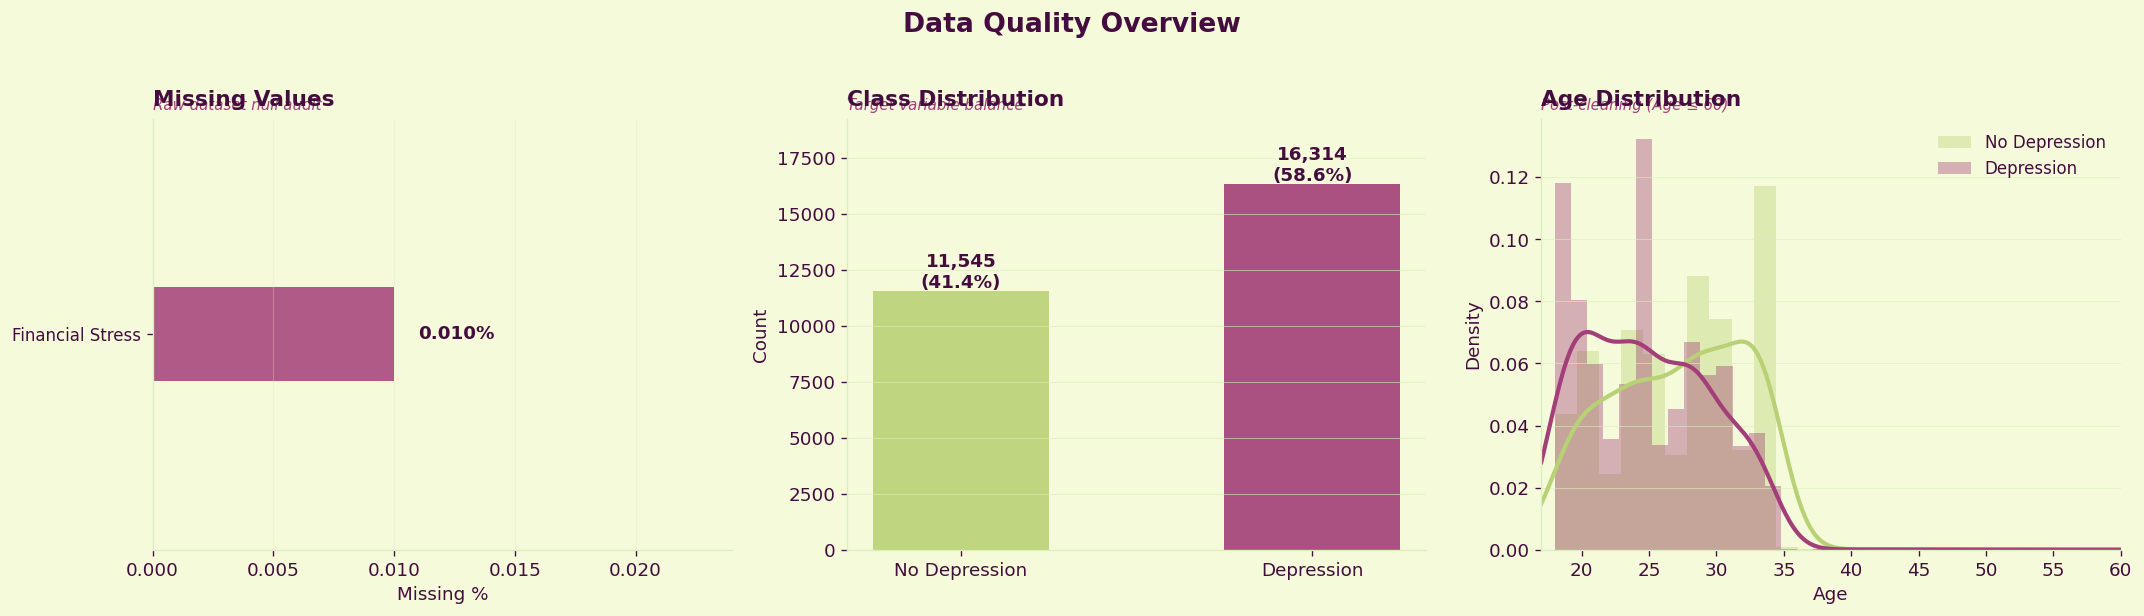

In [5]:
from scipy.stats import gaussian_kde as _gkde

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(THEME['bg'])

# ── Panel 1: Missing values bar ────────────────────────────────────────────
ax = axes[0]
if not missing_report.empty:
    max_pct = missing_report['Pct'].max()
    bars = ax.barh(
        missing_report.index, missing_report['Pct'],
        color=THEME['accent'], alpha=0.85, height=0.35,
    )
    ax.set_xlim(0, max_pct * 2.4)
    for bar, val in zip(bars, missing_report['Pct']):
        ax.text(
            bar.get_width() + max_pct * 0.10,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}%', va='center', fontsize=11,
            color=THEME['dark'], fontweight='bold',
        )
    ax.set_xlabel('Missing %')
    ax.set_yticks(range(len(missing_report)))
    ax.set_yticklabels(missing_report.index, fontsize=10)
    ax.set_ylim(-0.8, len(missing_report) - 0.2)
    ax.grid(axis='x', alpha=0.4)
    ax.grid(axis='y', alpha=0)
else:
    ax.text(0.5, 0.5, 'No Missing Values', transform=ax.transAxes,
            ha='center', va='center', fontsize=14, color=THEME['primary'],
            fontweight='bold')
    ax.set_axis_off()
styled_ax(ax, 'Missing Values', 'Raw dataset null audit')

# ── Panel 2: Class balance ─────────────────────────────────────────────────
ax = axes[1]
counts = df_clean['Depression'].value_counts().sort_index()
bars = ax.bar(
    ['No Depression', 'Depression'], counts.values,
    color=PALETTE_LIST, alpha=0.9, width=0.5,
)
for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11,
        color=THEME['dark'], fontweight='bold',
    )
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.18)
styled_ax(ax, 'Class Distribution', 'Target variable balance')

# ── Panel 3: Age distribution — scipy KDE (no duplicate legend labels) ────
ax = axes[2]
age_min = df_clean['Age'].min() - 1
age_max = df_clean['Age'].max() + 1
xs = np.linspace(age_min, age_max, 300)

for cls, color, label in [(0, C_NO, 'No Depression'), (1, C_YES, 'Depression')]:
    subset = df_clean[df_clean['Depression'] == cls]['Age'].dropna().values
    ax.hist(subset, bins=25, color=color, alpha=0.40, density=True, label=label)
    kde_fn = _gkde(subset, bw_method=0.35)
    ax.plot(xs, kde_fn(xs), color=color, linewidth=2.5)

ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_xlim(age_min, age_max)
ax.legend(frameon=False, fontsize=10)
styled_ax(ax, 'Age Distribution', 'Post-cleaning (Age ≤ 60)')

plt.suptitle('Data Quality Overview', fontsize=16, fontweight='bold',
             color=THEME['dark'], y=1.02)
plt.tight_layout()
save_fig(fig, 'dqa_overview.png')
plt.show()

> **Insight**
> Only `Financial Stress` had missing values (~3 rows, < 0.02%). All other fields were complete.
> Age distribution is near-normal (18–30), with a small tail of mature students that was removed above 60.
> Class imbalance is moderate: approximately 58% of students are depressed — manageable with `class_weight='balanced'`.

---
## 2. Exploratory Data Analysis

We explore distributions, relationships, and patterns that inform the modeling strategy.

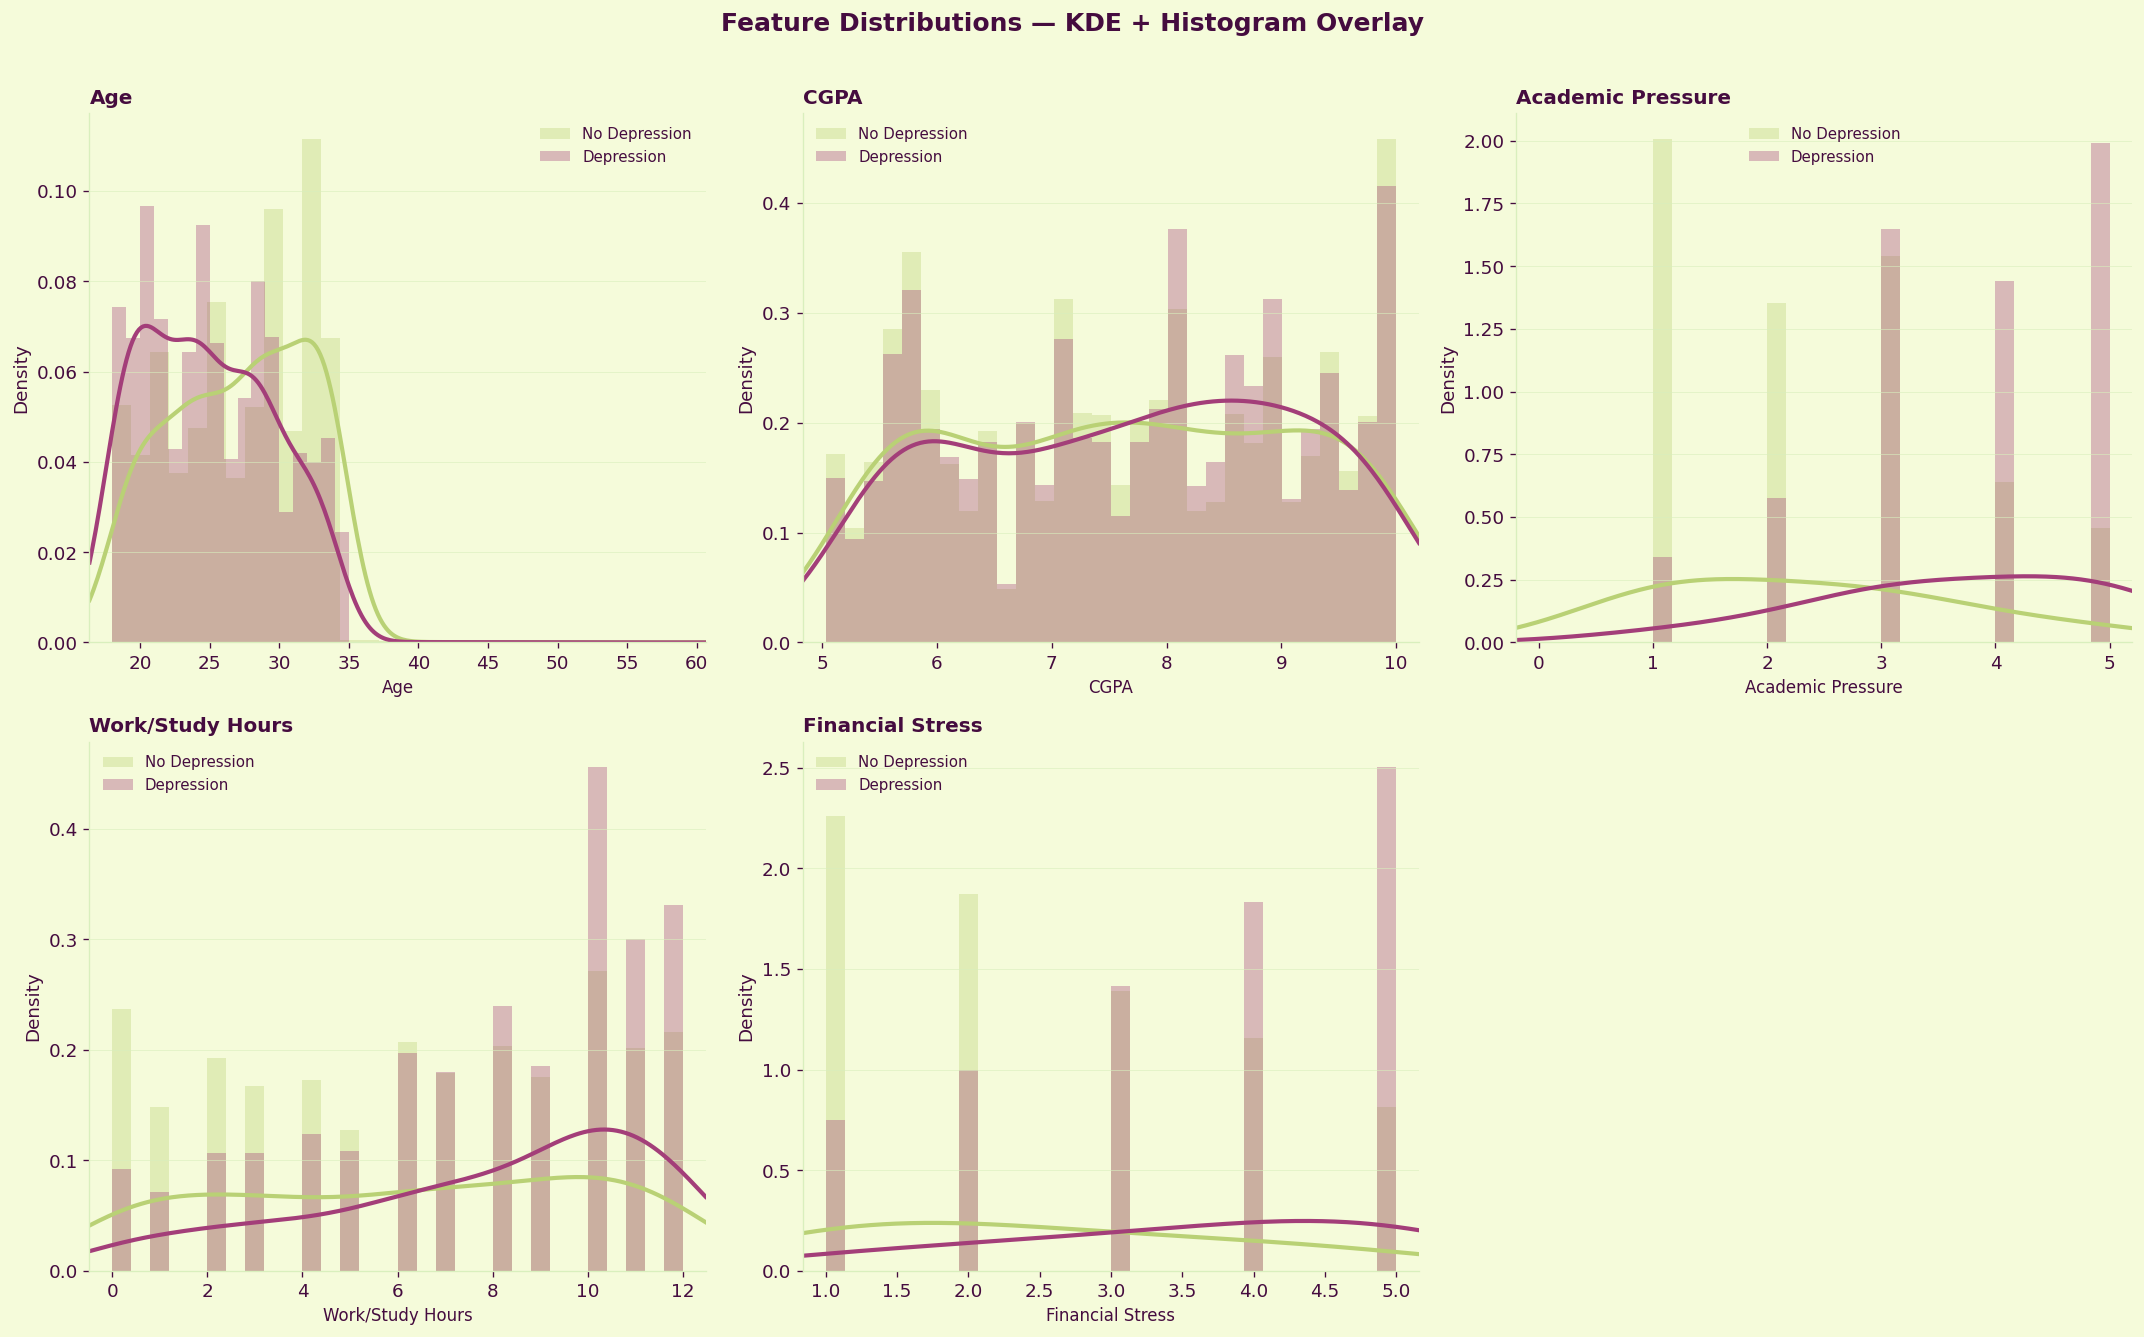

In [6]:
NUMERIC_COLS = ['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress']
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df_clean.columns]

from scipy.stats import gaussian_kde as _gkde_eda

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
fig.patch.set_facecolor(THEME['bg'])

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    col_all = df_clean[col].dropna()
    x_min, x_max = col_all.min(), col_all.max()
    x_pad = (x_max - x_min) * 0.04        # proportional padding — no negatives
    xs = np.linspace(x_min - x_pad, x_max + x_pad, 300)

    # Discrete variables (≤10 unique values: Academic Pressure, Financial Stress)
    # need a wider bandwidth to avoid spikes at each integer value
    bw = 0.65 if col_all.nunique() <= 10 else 0.35

    for cls, color, label in [(0, C_NO, 'No Depression'), (1, C_YES, 'Depression')]:
        data = df_clean[df_clean['Depression'] == cls][col].dropna().values
        ax.hist(data, bins=30, color=color, alpha=0.35, density=True, label=label)
        kde_fn = _gkde_eda(data, bw_method=bw)
        ax.plot(xs, kde_fn(xs), color=color, linewidth=2.5)

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(frameon=False, fontsize=9)

    # Single-line title — no subtitle so nothing overlaps
    ax.set_title(col, fontweight='bold', fontsize=12, loc='left',
                 color=THEME['dark'], pad=6)
    ax.spines['left'].set_color(THEME['secondary'])
    ax.spines['bottom'].set_color(THEME['secondary'])

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions — KDE + Histogram Overlay',
             fontsize=15, fontweight='bold', color=THEME['dark'], y=1.01)
plt.tight_layout()
save_fig(fig, 'kde_distributions.png')
plt.show()

> **Insight**
> **Academic Pressure** and **Financial Stress** show the clearest separation between classes — depressed students cluster at higher values.
> **CGPA** shows the opposite: depressed students tend to have lower GPAs, suggesting academic underperformance as both a symptom and a stressor.

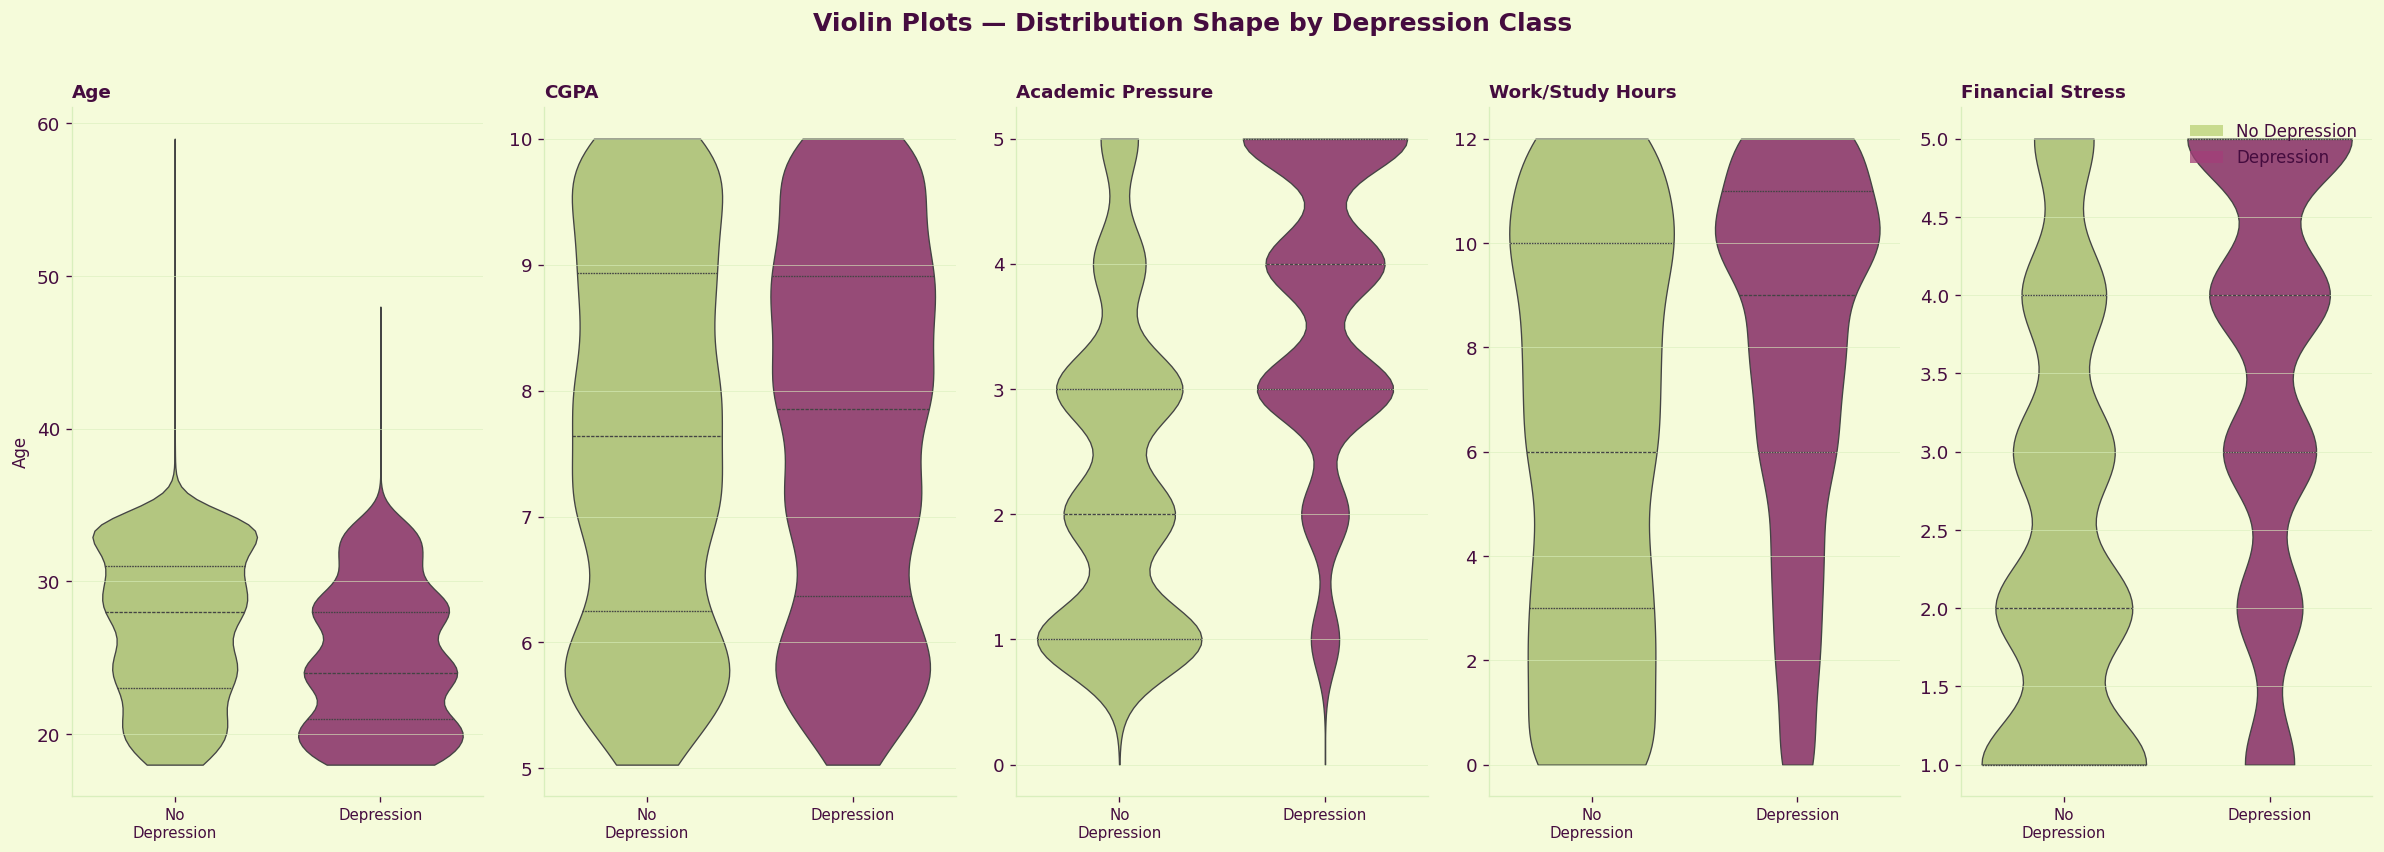

In [7]:
fig, axes = plt.subplots(1, len(NUMERIC_COLS), figsize=(20, 7))
fig.patch.set_facecolor(THEME['bg'])

# Legend patches (drawn once, placed on last axis)
legend_patches = [
    mpatches.Patch(facecolor=C_NO,  alpha=0.75, label='No Depression'),
    mpatches.Patch(facecolor=C_YES, alpha=0.75, label='Depression'),
]

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]

    # seaborn violinplot — bw_adjust controls smoothness:
    # 1.5 merges the integer-value bumps into one fluid shape
    sns.violinplot(
        data=df_clean,
        x='Depression', y=col,
        hue='Depression',
        palette=PALETTE,
        inner='quart',   # quartile lines inside
        cut=0,           # don't extend tails beyond data range
        bw_adjust=1.5,   # wider bandwidth → smooth, no integer spikes
        linewidth=0.8,
        legend=False,
        ax=ax,
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No\nDepression', 'Depression'], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel(col if i == 0 else '', fontsize=10)
    ax.set_title(col, fontweight='bold', fontsize=11, loc='left', color=THEME['dark'], pad=6)
    ax.spines['left'].set_color(THEME['secondary'])
    ax.spines['bottom'].set_color(THEME['secondary'])

# Single shared legend on the last axis
axes[-1].legend(
    handles=legend_patches, frameon=False,
    fontsize=10, loc='upper right',
)

plt.suptitle('Violin Plots — Distribution Shape by Depression Class',
             fontsize=15, fontweight='bold', color=THEME['dark'], y=1.01)
plt.tight_layout()
save_fig(fig, 'violin_plots.png')
plt.show()

In [8]:
# ── Sankey: Suicidal Thoughts -> Depression ────────────────────────────────
st_col  = 'Have you ever had suicidal thoughts ?'
fh_col  = 'Family History of Mental Illness'
tgt_col = 'Depression'

# Compute flows: (ST, FH) -> Depression
flows = (
    df_clean.groupby([st_col, fh_col, tgt_col])
    .size().reset_index(name='n')
)

# Node order:
# 0: ST No    1: ST Yes
# 2: FH No    3: FH Yes
# 4: No Dep   5: Dep
st_map = {'No': 0, 'Yes': 1}
fh_map = {'No': 2, 'Yes': 3}
tg_map = {0: 4, 1: 5}

src, tgt, val = [], [], []
# Layer 1: ST -> FH
for (st, fh), grp in flows.groupby([st_col, fh_col]):
    src.append(st_map[st]); tgt.append(fh_map[fh]); val.append(grp['n'].sum())
# Layer 2: FH -> Depression
for (fh, dep), grp in flows.groupby([fh_col, tgt_col]):
    src.append(fh_map[fh]); tgt.append(tg_map[dep]); val.append(grp['n'].sum())

node_colors = [
    f"rgba(185,209,117,0.85)",  # ST No
    f"rgba(163,62,121,0.85)",   # ST Yes
    f"rgba(185,209,117,0.70)",  # FH No
    f"rgba(163,62,121,0.70)",   # FH Yes
    f"rgba(185,209,117,0.95)",  # No Depression
    f"rgba(163,62,121,0.95)",   # Depression
]

fig_sankey = go.Figure(go.Sankey(
    arrangement='snap',
    textfont=dict(size=12, color=THEME['dark']),
    node=dict(
        label=['No Suicidal\nThoughts', 'Had Suicidal\nThoughts',
               'No Family\nHistory', 'Family\nHistory',
               'Not\nDepressed', 'Depressed'],
        color=node_colors,
        pad=20, thickness=22,
        line=dict(color=THEME['dark'], width=0.5),
    ),
    link=dict(
        source=src, target=tgt, value=val,
        color=[f'rgba(69,12,63,0.15)'] * len(src),
    ),
))

fig_sankey.update_layout(
    title=dict(text='Patient Flow: Suicidal Thoughts → Family History → Depression',
               font=dict(size=17, color=THEME['dark'])),
    **PL,
)
fig_sankey.show()

> **Insight**
> Students who have had suicidal thoughts are dramatically more likely to be depressed — and family history amplifies this risk further.
> The sankey reveals that the path **Suicidal Thoughts YES + Family History YES** flows almost entirely into the Depressed node.

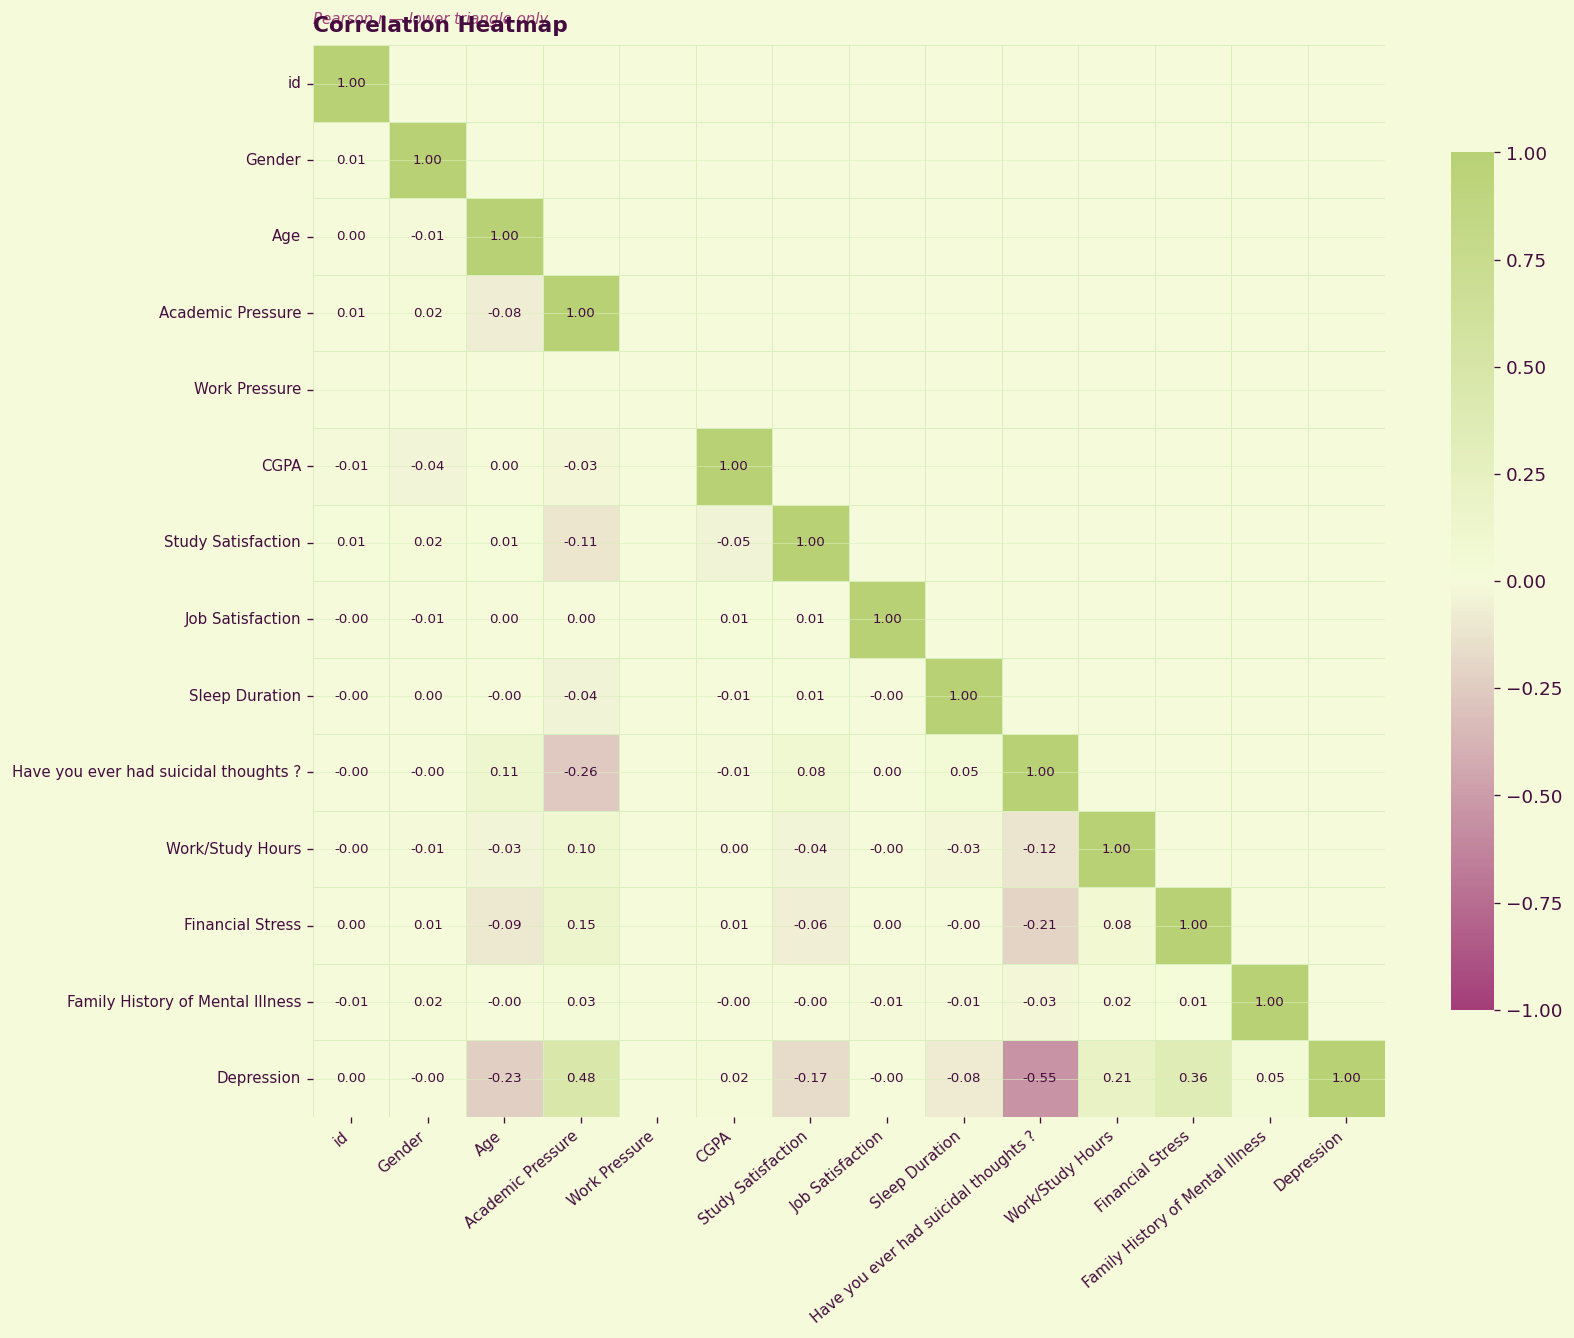

Top 8 correlations with Depression:
Have you ever had suicidal thoughts ?    0.546
Academic Pressure                        0.475
Financial Stress                         0.364
Age                                      0.227
Work/Study Hours                         0.209
Study Satisfaction                       0.168
Sleep Duration                           0.080
Family History of Mental Illness         0.053


In [9]:
def encode_for_corr(df):
    d = df.copy()
    sleep_map = {'Less than 5 hours': 1, '5-6 hours': 2, '6-7 hours': 3,
                 '7-8 hours': 4, 'More than 8 hours': 5}
    if 'Sleep Duration' in d.columns:
        d['Sleep Duration'] = d['Sleep Duration'].map(sleep_map)
    for col in ['Have you ever had suicidal thoughts ?',
                'Family History of Mental Illness', 'Gender']:
        if col in d.columns:
            u = d[col].dropna().unique()
            if len(u) == 2:
                d[col] = d[col].map({u[0]: 0, u[1]: 1})
    obj = d.select_dtypes('object').columns.tolist()
    if obj:
        d = pd.get_dummies(d, columns=obj, drop_first=True)
    return d

df_enc  = encode_for_corr(df_clean)
df_num  = df_enc.select_dtypes(include=[np.number])
corr    = df_num.corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor(THEME['bg'])

sns.heatmap(
    corr, mask=mask, cmap=div_cmap, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8, 'color': THEME['dark']},
    linewidths=0.4, linecolor=THEME['secondary'],
    square=True, ax=ax, cbar_kws={'shrink': 0.7},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
styled_ax(ax, 'Correlation Heatmap', 'Pearson r — lower triangle only')
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
save_fig(fig, 'corr_heatmap.png')
plt.show()

print('Top 8 correlations with Depression:')
print(corr['Depression'].abs().sort_values(ascending=False).head(9).iloc[1:].round(3).to_string())

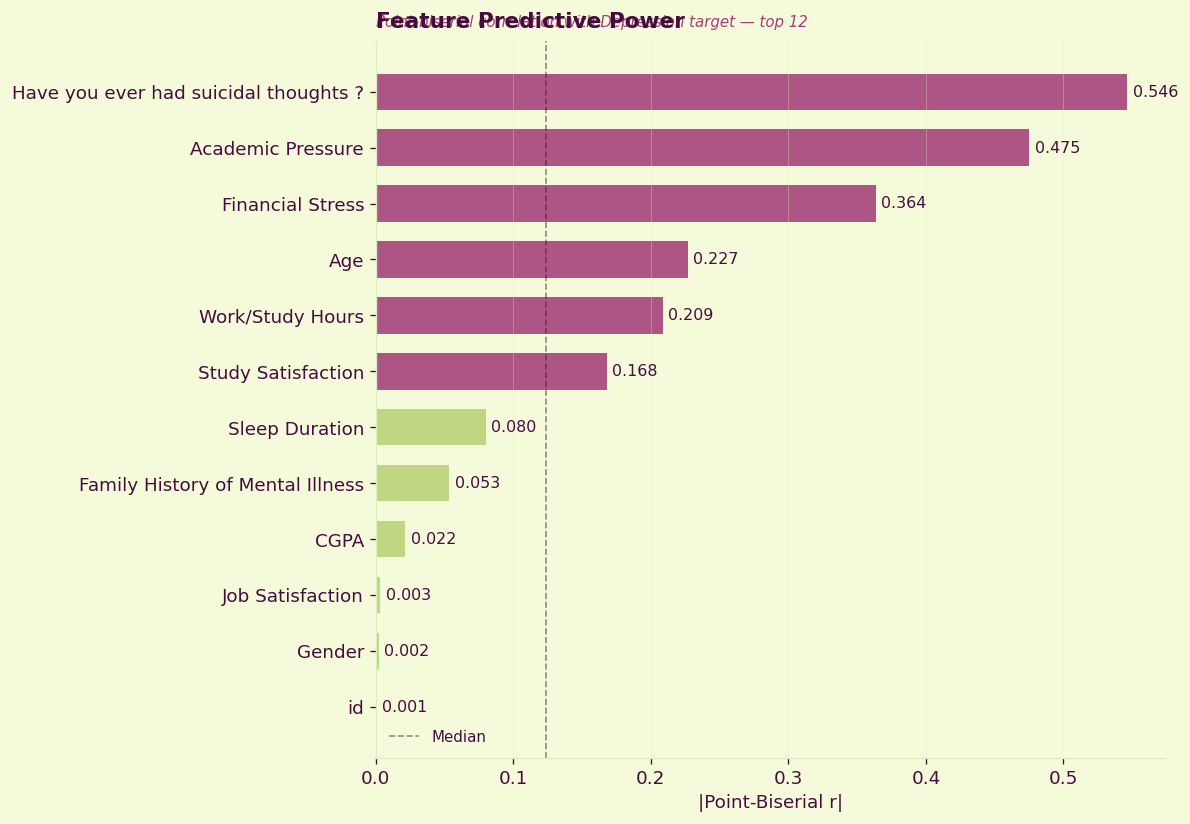

Top 5 predictive features: ['Have you ever had suicidal thoughts ?', 'Academic Pressure', 'Financial Stress', 'Age', 'Work/Study Hours']


In [10]:
corrs = {}
for col in df_num.columns:
    if col == 'Depression':
        continue
    v = df_num[[col, 'Depression']].dropna()
    if v[col].std() == 0:
        continue
    r, _ = pointbiserialr(v['Depression'], v[col])
    corrs[col] = r

pb = pd.Series(corrs).abs().sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(THEME['bg'])

colors = [THEME['accent'] if v > pb.median() else THEME['primary'] for v in pb.values]
bars = ax.barh(pb.index, pb.values, color=colors, alpha=0.88, height=0.65)
for bar, val in zip(bars, pb.values):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9.5, color=THEME['dark'])

ax.axvline(pb.median(), color=THEME['dark'], linestyle='--',
           linewidth=1, alpha=0.5, label='Median')
ax.set_xlabel('|Point-Biserial r|')
ax.legend(frameon=False, fontsize=9)
styled_ax(ax, 'Feature Predictive Power',
          'Point-biserial correlation with Depression target — top 12')
ax.grid(axis='x', alpha=0.4)
ax.grid(axis='y', alpha=0)

plt.tight_layout()
save_fig(fig, 'pb_correlation.png')
plt.show()

top5 = pb.sort_values(ascending=False).head(5).index.tolist()
top5_raw = [f for f in top5 if f in df_clean.columns]
print(f'Top 5 predictive features: {top5_raw}')

> **Insight**
> `Have you ever had suicidal thoughts?` is the single strongest predictor — highlighting the direct psychological dimension of depression.
> `Academic Pressure`, `Financial Stress`, and `Sleep Duration` form the next tier, confirming that environmental and behavioral stressors are the core drivers.

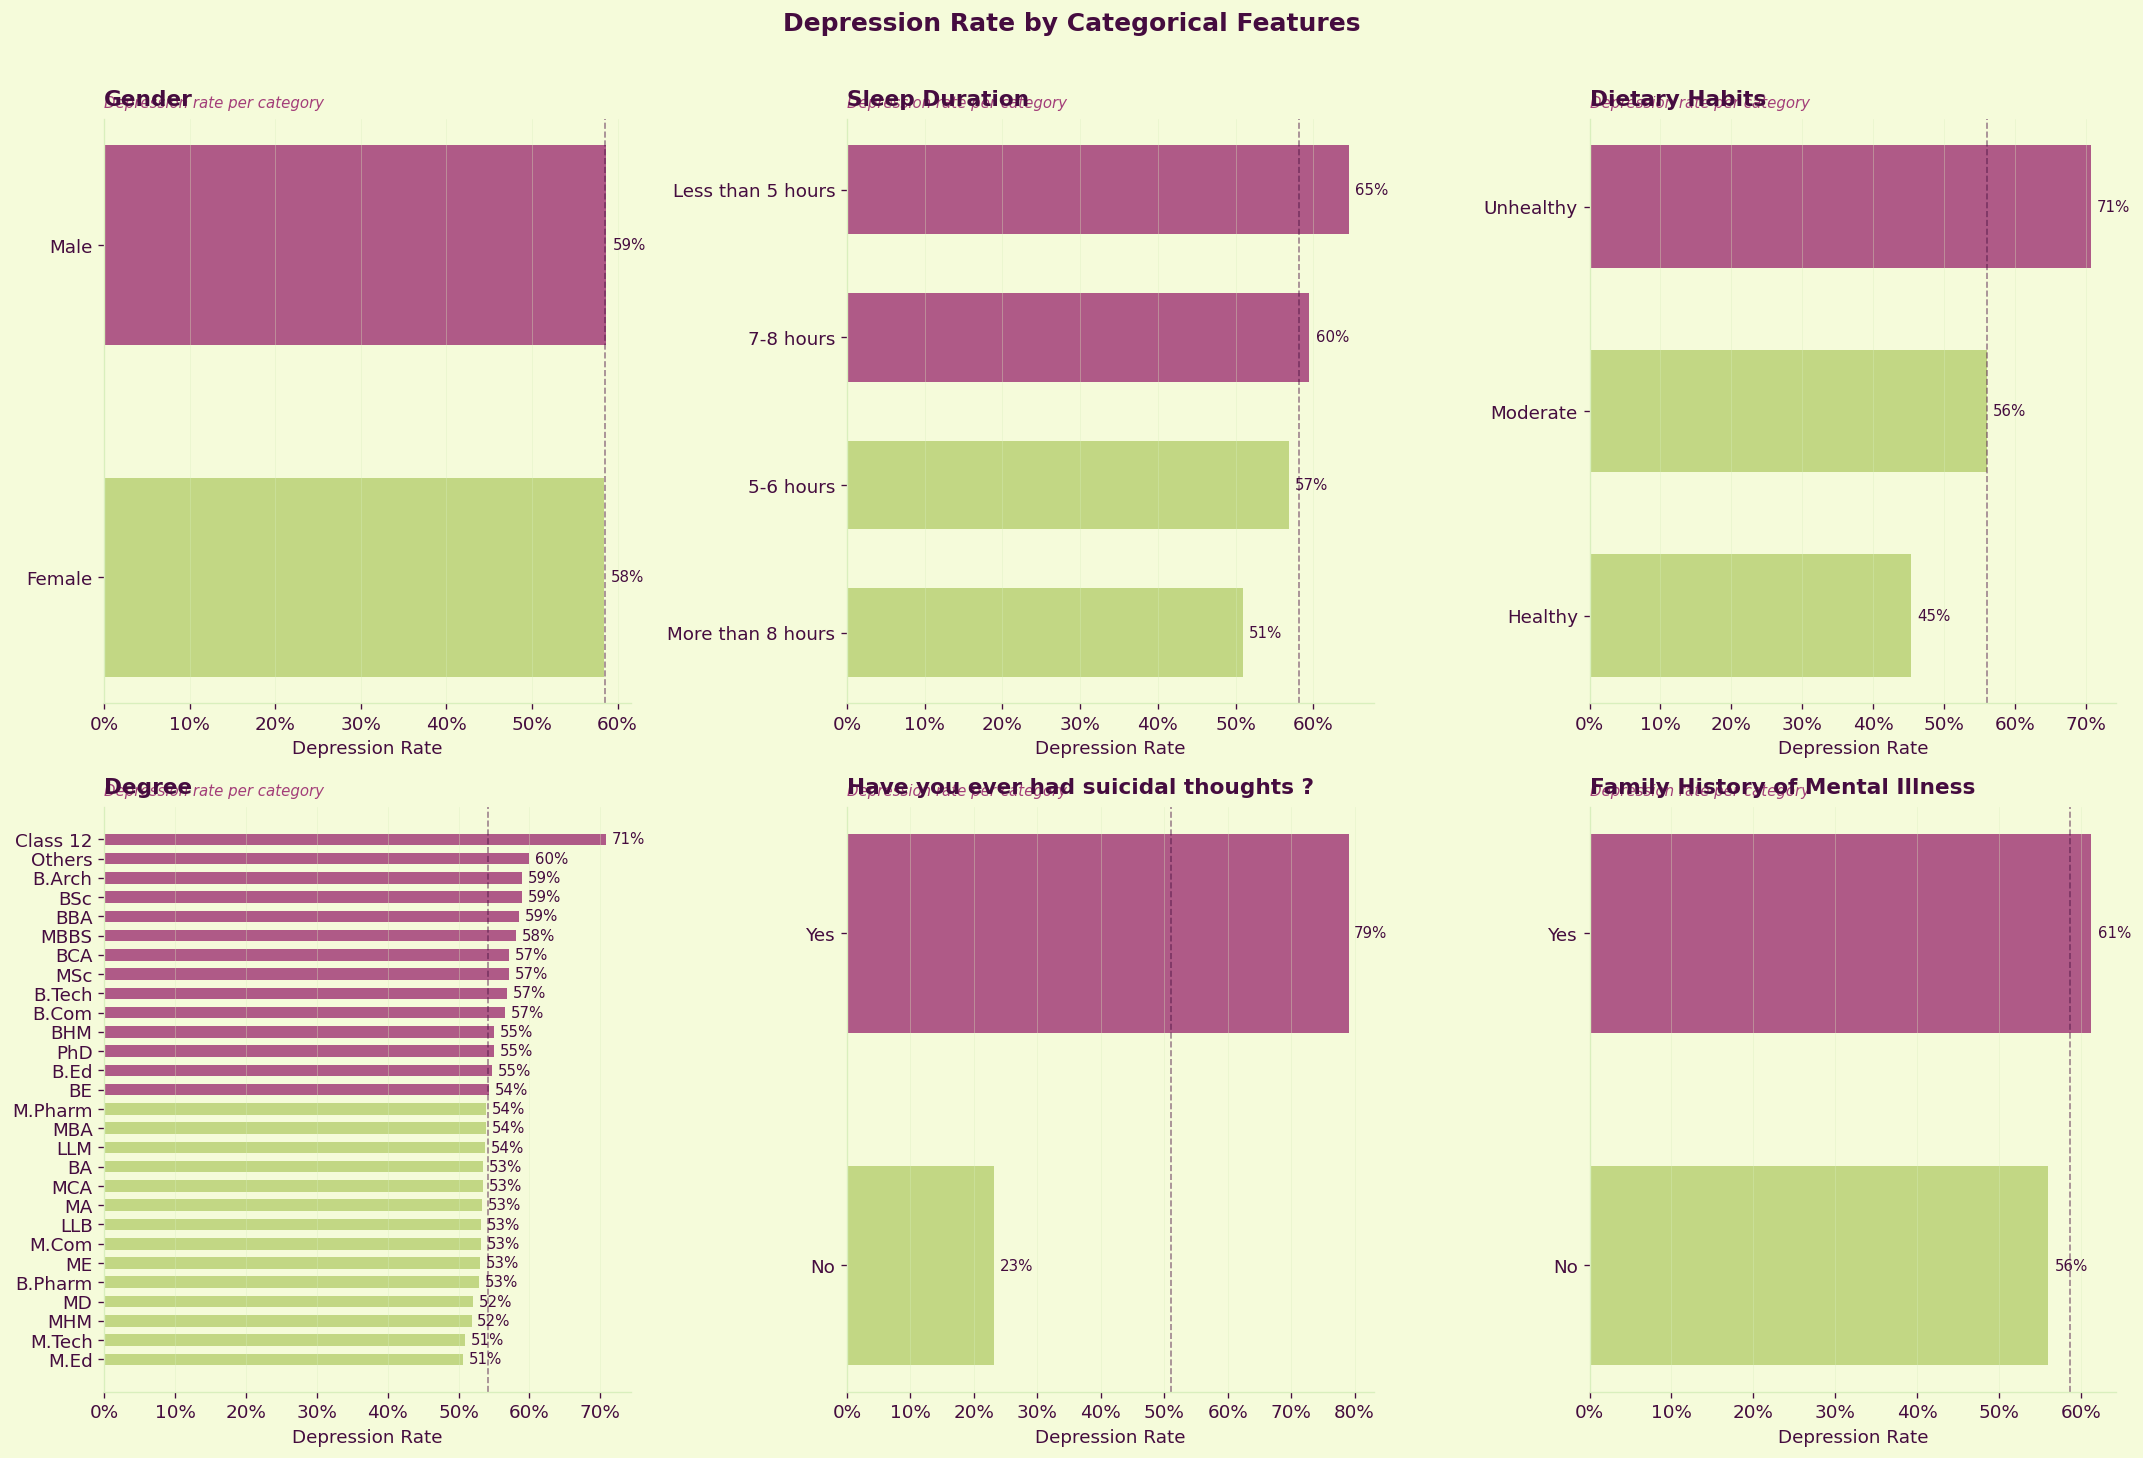

In [11]:
CAT_COLS = ['Gender', 'Sleep Duration', 'Dietary Habits', 'Degree',
            'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
CAT_COLS = [c for c in CAT_COLS if c in df_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
fig.patch.set_facecolor(THEME['bg'])

for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    dep_rate = df_clean.groupby(col)['Depression'].mean().sort_values(ascending=True)
    counts   = df_clean[col].value_counts()
    dep_rate = dep_rate.reindex(dep_rate.index)

    colors = [THEME['accent'] if v > dep_rate.median() else THEME['primary']
              for v in dep_rate.values]
    bars = ax.barh(dep_rate.index.astype(str), dep_rate.values,
                   color=colors, alpha=0.85, height=0.6)
    ax.axvline(dep_rate.median(), color=THEME['dark'], linestyle='--',
               linewidth=1, alpha=0.5)
    for bar, val in zip(bars, dep_rate.values):
        ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
                f'{val:.0%}', va='center', fontsize=9, color=THEME['dark'])
    ax.set_xlabel('Depression Rate')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(axis='y', alpha=0)
    ax.grid(axis='x', alpha=0.4)
    styled_ax(ax, col, 'Depression rate per category')

for j in range(len(CAT_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Depression Rate by Categorical Features',
             fontsize=15, fontweight='bold', color=THEME['dark'], y=1.01)
plt.tight_layout()
save_fig(fig, 'categorical_depression_rate.png')
plt.show()

In [12]:
counts = df_clean['Depression'].value_counts().sort_index()

fig_donut = go.Figure(go.Pie(
    labels=['No Depression', 'Depression'],
    values=counts.values,
    hole=0.55,
    marker=dict(
        colors=[THEME['primary'], THEME['accent']],
        line=dict(color=THEME['bg'], width=3),
    ),
    textinfo='label+percent',
    textfont=dict(size=14, color=THEME['dark']),
    hovertemplate='%{label}<br>Count: %{value:,}<br>Share: %{percent}<extra></extra>',
))

fig_donut.add_annotation(
    text=f'<b>{counts.sum():,}</b><br>students',
    x=0.5, y=0.5, showarrow=False,
    font=dict(size=16, color=THEME['dark']),
    align='center',
)

fig_donut.update_layout(
    title=dict(text='Target Class Distribution', font=dict(size=18)),
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=-0.15),
    **PL,
)
fig_donut.show()

---
## 3. Feature Engineering

We transform raw columns into model-ready features:
1. Drop irrelevant columns (`id`, `City`, `Work Pressure`, `Job Satisfaction`, `Profession`)
2. Create interaction feature: `Academic Pressure × Sleep Duration`
3. Binary-encode Yes/No columns
4. Ordinal-encode Sleep Duration (1–5 scale)
5. One-hot encode Gender, Dietary Habits, Degree
6. MinMax scale all numeric features
7. 80/20 stratified split
8. RFE feature selection (top 15)

In [13]:
DROP_COLS   = ['id', 'Profession', 'Work Pressure', 'Job Satisfaction', 'City']
SLEEP_ORDER = ['Less than 5 hours', '5-6 hours', '6-7 hours', '7-8 hours', 'More than 8 hours']
SLEEP_MAP   = {v: i+1 for i, v in enumerate(SLEEP_ORDER)}
OHE_COLS    = ['Gender', 'Dietary Habits', 'Degree']
BINARY_MAP  = {
    'Have you ever had suicidal thoughts ?': {'Yes': 1, 'No': 0},
    'Family History of Mental Illness':      {'Yes': 1, 'No': 0},
}
FEAT_NUM    = ['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress']
N_RFE       = 15

def prepare_features(df):
    df = df.copy()
    y  = df['Depression'].values
    df = df.drop(columns=['Depression'])

    to_drop = [c for c in DROP_COLS if c in df.columns]
    if 'City' in df.columns and df['City'].nunique() > 20 and 'City' not in to_drop:
        to_drop.append('City')
    df.drop(columns=to_drop, errors='ignore', inplace=True)

    sl_enc = df['Sleep Duration'].map(SLEEP_MAP).fillna(3) if 'Sleep Duration' in df.columns else 3
    df['AP_x_Sleep'] = df['Academic Pressure'] * sl_enc

    for col, mapping in BINARY_MAP.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    if 'Sleep Duration' in df.columns:
        df['Sleep Duration'] = df['Sleep Duration'].map(SLEEP_MAP).fillna(3)

    num_feats  = [c for c in FEAT_NUM + ['AP_x_Sleep'] if c in df.columns]
    ohe_feats  = [c for c in OHE_COLS if c in df.columns]
    pass_feats = [c for c in df.columns if c not in num_feats and c not in ohe_feats]

    transformers = [
        ('num', MinMaxScaler(), num_feats),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_feats),
    ]
    if pass_feats:
        transformers.append(('pass', 'passthrough', pass_feats))
    prep = ColumnTransformer(transformers)

    Xtr_raw, Xte_raw, ytr, yte = train_test_split(
        df, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    Xtr = prep.fit_transform(Xtr_raw)
    Xte = prep.transform(Xte_raw)

    ohe_names = (
        prep.named_transformers_['ohe'].get_feature_names_out(ohe_feats).tolist()
        if ohe_feats else []
    )
    feat_names = num_feats + ohe_names + pass_feats

    rfe = RFE(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        n_features_to_select=min(N_RFE, Xtr.shape[1]), step=1
    )
    rfe.fit(Xtr, ytr)

    sel = [f for f, s in zip(feat_names, rfe.support_) if s]
    dropped = [f for f, s in zip(feat_names, rfe.support_) if not s]

    print(f'Selected ({len(sel)}): {sel}')
    print(f'Dropped  ({len(dropped)}): {dropped}')

    return rfe.transform(Xtr), rfe.transform(Xte), ytr, yte, sel, prep, rfe, Xte_raw


X_train, X_test, y_train, y_test, selected_features, preprocessor, rfe, X_test_raw = prepare_features(df_clean)
print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')

Selected (15): ['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress', 'Gender_Female', 'Gender_Male', 'Dietary Habits_Healthy', 'Dietary Habits_Moderate', 'Degree_BA', 'Degree_LLM', 'Degree_ME', 'Study Satisfaction', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
Dropped  (28): ['AP_x_Sleep', 'Dietary Habits_Unhealthy', 'Degree_B.Arch', 'Degree_B.Com', 'Degree_B.Ed', 'Degree_B.Pharm', 'Degree_B.Tech', 'Degree_BBA', 'Degree_BCA', 'Degree_BE', 'Degree_BHM', 'Degree_BSc', 'Degree_Class 12', 'Degree_LLB', 'Degree_M.Com', 'Degree_M.Ed', 'Degree_M.Pharm', 'Degree_M.Tech', 'Degree_MA', 'Degree_MBA', 'Degree_MBBS', 'Degree_MCA', 'Degree_MD', 'Degree_MHM', 'Degree_MSc', 'Degree_Others', 'Degree_PhD', 'Sleep Duration']

Train: (22287, 15) | Test: (5572, 15)


### EDA Add-ons: Train/Test Drift, Missingness Pattern, and PCA Projection

These lightweight diagnostics close the remaining EDA checklist items: missingness pattern visualization, train-vs-test distribution comparison, and multivariate projection.


In [ ]:
import missingno as msno
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Missingness pattern visualization on raw data before cleaning.
msno.matrix(df_raw, figsize=(12, 4), color=tuple(int(THEME['accent'].lstrip('#')[i:i+2], 16)/255 for i in (0, 2, 4)))
plt.title('Missingness Pattern in Raw Dataset', fontsize=14)
plt.show()

# Recreate the same raw split used by prepare_features for a train-vs-test drift check.
_raw_X = df_clean.drop(columns=['Depression'])
_raw_y = df_clean['Depression']
raw_train, raw_test, _, _ = train_test_split(
    _raw_X, _raw_y, test_size=0.2, random_state=RANDOM_STATE, stratify=_raw_y
)

drift_rows = []
for col in NUMERIC_COLS:
    if col in raw_train.columns:
        stat, pval = ks_2samp(raw_train[col].dropna(), raw_test[col].dropna())
        drift_rows.append({
            'feature': col,
            'train_mean': raw_train[col].mean(),
            'test_mean': raw_test[col].mean(),
            'mean_diff': raw_test[col].mean() - raw_train[col].mean(),
            'ks_stat': stat,
            'ks_pvalue': pval,
        })

drift_df = pd.DataFrame(drift_rows).sort_values('ks_stat', ascending=False)
display(
    drift_df.style
    .format({'train_mean': '{:.3f}', 'test_mean': '{:.3f}', 'mean_diff': '{:.3f}', 'ks_stat': '{:.4f}', 'ks_pvalue': '{:.4f}'})
    .set_caption('Train vs Test Distribution Check (Numeric Features)')
)

cat_drift_rows = []
for col in CAT_COLS:
    if col in raw_train.columns:
        tr = raw_train[col].value_counts(normalize=True)
        te = raw_test[col].value_counts(normalize=True)
        for level in sorted(set(tr.index).union(set(te.index))):
            cat_drift_rows.append({
                'feature': col,
                'level': level,
                'train_pct': tr.get(level, 0.0),
                'test_pct': te.get(level, 0.0),
                'abs_pct_diff': abs(te.get(level, 0.0) - tr.get(level, 0.0)),
            })

cat_drift_df = pd.DataFrame(cat_drift_rows).sort_values('abs_pct_diff', ascending=False).head(15)
display(
    cat_drift_df.style
    .format({'train_pct': '{:.2%}', 'test_pct': '{:.2%}', 'abs_pct_diff': '{:.2%}'})
    .set_caption('Largest Train/Test Categorical Distribution Differences')
)

# Multivariate projection using the selected model-ready features.
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_vis = np.vstack([X_train, X_test])
y_vis = np.concatenate([y_train, y_test])
split_vis = np.array(['Train'] * len(X_train) + ['Test'] * len(X_test))
coords = pca2.fit_transform(X_vis)

pca_df = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'Depression': np.where(y_vis == 1, 'Depression', 'No Depression'),
    'Split': split_vis,
})

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(THEME['bg'])
sample_plot = pca_df.sample(min(3500, len(pca_df)), random_state=RANDOM_STATE)
sns.scatterplot(
    data=sample_plot, x='PC1', y='PC2', hue='Depression', style='Split',
    palette={'No Depression': THEME['primary'], 'Depression': THEME['accent']},
    alpha=0.55, s=24, ax=ax
)
styled_ax(ax, 'PCA Projection of Model-Ready Features', 'Multivariate view colored by target and split')
plt.tight_layout()
plt.show()


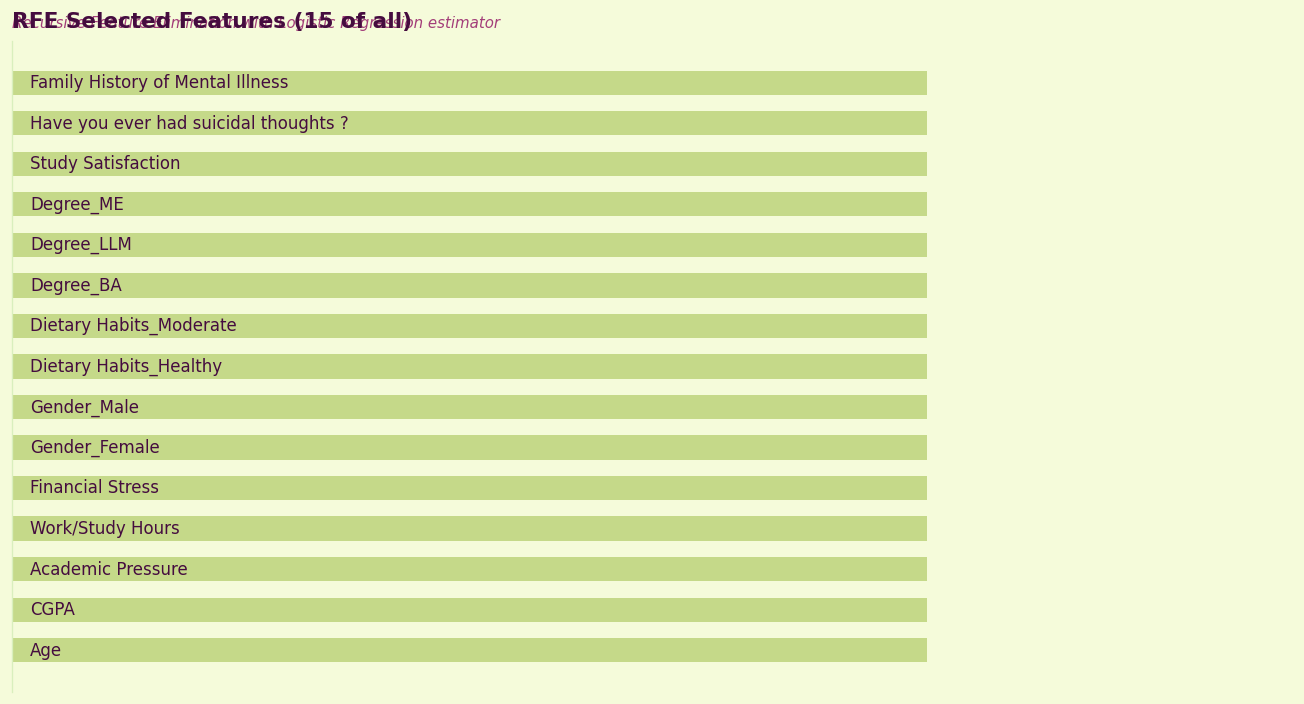

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(THEME['bg'])

n_total = len(selected_features) + len(
    [f for f, s in zip(selected_features, rfe.support_) if not s]
)
bars = ax.barh(range(len(selected_features)), [1]*len(selected_features),
               color=THEME['primary'], alpha=0.8, height=0.6)
for j, feat in enumerate(selected_features):
    ax.text(0.02, j, feat, va='center', ha='left', fontsize=10, color=THEME['dark'])
ax.set_xlim(0, 1.4)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
styled_ax(ax, f'RFE Selected Features ({len(selected_features)} of all)',
          'Recursive Feature Elimination with Logistic Regression estimator')

plt.tight_layout()
save_fig(fig, 'rfe_features.png')
plt.show()

---
## 4. Model Training

Five classifiers trained with **Stratified 5-Fold Cross-Validation**. Class imbalance handled with `class_weight='balanced'`. Best model then fine-tuned with `GridSearchCV`.

In [15]:
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    'f1_macro':        'f1_macro',
    'roc_auc':         'roc_auc',
    'accuracy':        'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro':    'recall_macro',
}

def cv_scores(model, X, y):
    res = cross_validate(model, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    return {m + s: float(np.mean(res[f'test_{m}']) if s=='_mean'
                         else np.std(res[f'test_{m}']))
            for m in SCORING for s in ('_mean', '_std')}

n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
spw   = n_neg / n_pos if n_pos > 0 else 1.0

model_specs = [
    ('Logistic Regression',
     LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
     {'class_weight': 'balanced'}),
    ('Decision Tree',
     DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=RANDOM_STATE),
     {'max_depth': 5}),
    ('Random Forest',
     RandomForestClassifier(class_weight='balanced', n_estimators=200,
                            random_state=RANDOM_STATE, n_jobs=-1),
     {'n_estimators': 200}),
    ('Support Vector Machine',
     LinearSVC(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
     {'kernel': 'linear', 'class_weight': 'balanced'}),
    ('Neural Network (MLP)',
     MLPClassifier(hidden_layer_sizes=(32,), activation='relu', early_stopping=True,
                   max_iter=250, random_state=RANDOM_STATE),
     {'hidden_layer_sizes': (32,), 'early_stopping': True}),
]
if HAS_XGB:
    model_specs.append((
        'XGBoost',
        XGBClassifier(scale_pos_weight=spw, n_estimators=200,
                      random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
        {'scale_pos_weight': round(spw, 3)},
    ))
if HAS_LGB:
    model_specs.append((
        'LightGBM',
        LGBMClassifier(is_unbalance=True, n_estimators=200,
                       random_state=RANDOM_STATE, verbose=-1),
        {'is_unbalance': True},
    ))

records = []
for name, model, _ in model_specs:
    print(f'Training {name} ...', end=' ')
    t0 = time.time()
    sc = cv_scores(model, X_train, y_train)
    elapsed = time.time() - t0
    records.append({'model': name, 'time_s': round(elapsed, 1), **sc})
    print(f'F1={sc["f1_macro_mean"]:.4f} | AUC={sc["roc_auc_mean"]:.4f} | {elapsed:.1f}s')

results_df = pd.DataFrame(records).sort_values('f1_macro_mean', ascending=False).reset_index(drop=True)
print('\nBase training complete.')


Training Logistic Regression ... F1=0.8388 | AUC=0.9195 | 4.5s
Training Decision Tree ... F1=0.8156 | AUC=0.8946 | 0.4s
Training Random Forest ... F1=0.8304 | AUC=0.9102 | 18.6s
Training XGBoost ... F1=0.8233 | AUC=0.9010 | 2.3s
Training LightGBM ... F1=0.8369 | AUC=0.9140 | 4.6s

Base training complete.


In [16]:
best_base = results_df.iloc[0]['model']
print(f'Best base model: {best_base} — running GridSearchCV...')

if 'Random Forest' in best_base:
    base_est = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    pgrid = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
elif 'XGBoost' in best_base and HAS_XGB:
    base_est = XGBClassifier(scale_pos_weight=spw, random_state=RANDOM_STATE,
                             eval_metric='logloss', verbosity=0)
    pgrid = {'learning_rate': [0.05, 0.1], 'max_depth': [4, 6],
             'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}
elif 'LightGBM' in best_base and HAS_LGB:
    base_est = LGBMClassifier(is_unbalance=True, random_state=RANDOM_STATE, verbose=-1)
    pgrid = {'learning_rate': [0.05, 0.1], 'max_depth': [4, 6],
             'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}
elif 'Support Vector Machine' in best_base:
    from sklearn.svm import LinearSVC
    base_est = LinearSVC(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    pgrid = {'C': [0.1, 1.0, 10.0]}
elif 'Neural Network' in best_base:
    from sklearn.neural_network import MLPClassifier
    base_est = MLPClassifier(hidden_layer_sizes=(32,), early_stopping=True, max_iter=250, random_state=RANDOM_STATE)
    pgrid = {'alpha': [0.0001, 0.001, 0.01], 'learning_rate_init': [0.001, 0.01]}
else:
    base_est = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    pgrid = {'C': [0.01, 0.1, 1.0, 10.0]}

grid = GridSearchCV(base_est, pgrid, cv=CV, scoring='f1_macro', n_jobs=-1, refit=True)
t0   = time.time()
grid.fit(X_train, y_train)
elap = time.time() - t0

best_model = grid.best_estimator_
print(f'Best params: {grid.best_params_}')
print(f'GridSearch CV F1: {grid.best_score_:.4f} | Time: {elap:.1f}s')

tuned_sc = cv_scores(best_model, X_train, y_train)
records.append({'model': best_base + ' (Tuned)', 'time_s': round(elap, 1), **tuned_sc})

best_model.fit(X_train, y_train)
with open(f'{MODELS_DIR}/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print('Model saved.')

results_df = pd.DataFrame(records).sort_values('f1_macro_mean', ascending=False).reset_index(drop=True)


Best base model: Logistic Regression — running GridSearchCV...
Best params: {'C': 0.1}
GridSearch CV F1: 0.8397 | Time: 1.8s
Model saved.


--- 
## 4b. Proposal Closure: OOF Predictions, MLflow, and Optuna

The proposal promised experiment tracking, out-of-fold validation artifacts, and Bayesian-style tuning. This section adds those items without changing the core modeling objective.


In [ ]:
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.base import clone

# Out-of-fold predictions for stacking/validation evidence.
oof_pred = cross_val_predict(clone(best_model), X_train, y_train, cv=CV, n_jobs=-1)

if hasattr(best_model, 'predict_proba'):
    oof_score_raw = cross_val_predict(clone(best_model), X_train, y_train, cv=CV, method='predict_proba', n_jobs=-1)[:, 1]
elif hasattr(best_model, 'decision_function'):
    oof_score_raw = cross_val_predict(clone(best_model), X_train, y_train, cv=CV, method='decision_function', n_jobs=-1)
else:
    oof_score_raw = oof_pred

oof_df = pd.DataFrame({
    'row_id': np.arange(len(y_train)),
    'y_true': y_train,
    'oof_pred': oof_pred,
    'oof_score': oof_score_raw,
})
oof_df.to_csv(f'{REPORTS_DIR}/oof_predictions.csv', index=False)

oof_summary = pd.DataFrame([{
    'OOF F1-macro': f1_score(y_train, oof_pred, average='macro'),
    'OOF Accuracy': accuracy_score(y_train, oof_pred),
    'OOF Precision-macro': precision_score(y_train, oof_pred, average='macro', zero_division=0),
    'OOF Recall-macro': recall_score(y_train, oof_pred, average='macro', zero_division=0),
}])
display(oof_summary.style.format('{:.4f}').set_caption('Out-of-Fold Prediction Summary'))

# Minimal MLflow tracking. If MLflow is unavailable, keep a local CSV fallback.
mlflow_status = 'not run'
try:
    import mlflow
    mlflow.set_experiment('student_depression_seng352')
    for _, row in results_df.iterrows():
        with mlflow.start_run(run_name=str(row['model']), nested=False):
            mlflow.log_param('model_name', str(row['model']))
            mlflow.log_metric('cv_f1_macro_mean', float(row['f1_macro_mean']))
            mlflow.log_metric('cv_f1_macro_std', float(row['f1_macro_std']))
            mlflow.log_metric('cv_roc_auc_mean', float(row['roc_auc_mean']))
            mlflow.log_metric('cv_accuracy_mean', float(row['accuracy_mean']))
            mlflow.log_metric('time_s', float(row['time_s']))
    mlflow_status = 'logged to local MLflow experiment: student_depression_seng352'
except Exception as e:
    mlflow_status = f'MLflow skipped; CSV fallback saved ({type(e).__name__}: {e})'

results_df.to_csv(f'{REPORTS_DIR}/model_tracking_fallback.csv', index=False)
print('MLflow status:', mlflow_status)

# Optuna Bayesian optimization for Logistic Regression C.
optuna_status = 'not run'
optuna_best = None
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        c = trial.suggest_float('C', 1e-3, 10.0, log=True)
        clf = LogisticRegression(C=c, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
        return cross_val_score(clf, X_train, y_train, cv=CV, scoring='f1_macro', n_jobs=-1).mean()

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=15, show_progress_bar=False)
    optuna_best = {'best_C': study.best_params['C'], 'best_cv_f1_macro': study.best_value}
    optuna_status = 'completed'
except Exception as e:
    optuna_status = f'Optuna skipped ({type(e).__name__}: {e})'

optuna_df = pd.DataFrame([{
    'status': optuna_status,
    'best_C': None if optuna_best is None else optuna_best['best_C'],
    'best_cv_f1_macro': None if optuna_best is None else optuna_best['best_cv_f1_macro'],
}])
display(optuna_df.style.format({'best_C': '{:.5f}', 'best_cv_f1_macro': '{:.4f}'}).set_caption('Optuna Bayesian Optimization Evidence'))

# Save a reproducible inference bundle.
bundle = {
    'model': best_model,
    'preprocessor': preprocessor,
    'rfe': rfe,
    'selected_features': selected_features,
    'random_state': RANDOM_STATE,
}
with open(f'{MODELS_DIR}/student_depression_pipeline_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print(f'OOF predictions saved to {REPORTS_DIR}/oof_predictions.csv')
print(f'Pipeline bundle saved to {MODELS_DIR}/student_depression_pipeline_bundle.pkl')


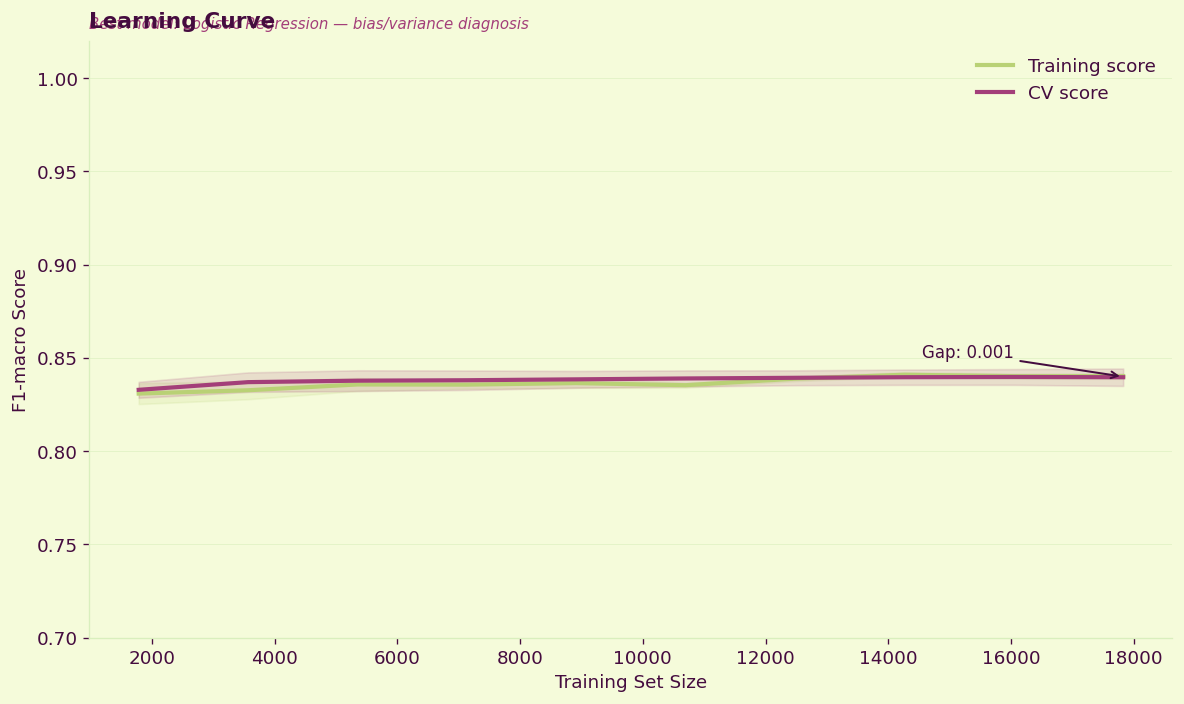

In [17]:
train_sizes, train_sc, val_sc = learning_curve(
    best_model, X_train, y_train,
    cv=CV, scoring='f1_macro', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
)

tr_mean, tr_std = train_sc.mean(axis=1), train_sc.std(axis=1)
vl_mean, vl_std = val_sc.mean(axis=1), val_sc.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(THEME['bg'])

ax.plot(train_sizes, tr_mean, color=THEME['primary'], lw=2.5, label='Training score')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color=THEME['primary'])
ax.plot(train_sizes, vl_mean, color=THEME['accent'], lw=2.5, label='CV score')
ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std,
                alpha=0.15, color=THEME['accent'])

gap = tr_mean[-1] - vl_mean[-1]
ax.annotate(f'Gap: {gap:.3f}',
            xy=(train_sizes[-1], (tr_mean[-1] + vl_mean[-1]) / 2),
            xytext=(train_sizes[-2] - 1500, (tr_mean[-1] + vl_mean[-1]) / 2 + 0.01),
            arrowprops=dict(arrowstyle='->', color=THEME['dark'], lw=1.2),
            fontsize=10, color=THEME['dark'])

ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1-macro Score')
ax.legend(frameon=False, fontsize=11)
ax.set_ylim(0.7, 1.02)
styled_ax(ax, 'Learning Curve', f'Best model: {best_base} — bias/variance diagnosis')

plt.tight_layout()
save_fig(fig, 'learning_curve.png')
plt.show()

---
## 5. Model Comparison

All models evaluated on the same 5-fold CV. Tuned model highlighted in the comparison.

In [18]:
metrics_radar = ['f1_macro_mean', 'roc_auc_mean', 'accuracy_mean',
                  'precision_macro_mean', 'recall_macro_mean']
metric_labels = ['F1-Macro', 'ROC-AUC', 'Accuracy', 'Precision', 'Recall']

colors_radar = [
    THEME['primary'], THEME['secondary'], '#C8A2C8',
    THEME['accent'], THEME['dark'], '#7B9E3A',
]

fig_radar = go.Figure()
for idx, row in results_df.iterrows():
    vals = [row[m] for m in metrics_radar]
    vals_closed = vals + [vals[0]]
    labels_closed = metric_labels + [metric_labels[0]]
    color = colors_radar[idx % len(colors_radar)]
    is_best = '(Tuned)' in row['model']
    fig_radar.add_trace(go.Scatterpolar(
        r=vals_closed,
        theta=labels_closed,
        fill='toself',
        name=row['model'],
        line=dict(color=color, width=3 if is_best else 1.5),
        opacity=0.85 if is_best else 0.45,
        fillcolor=color if is_best else 'rgba(0,0,0,0)',
    ))

fig_radar.update_layout(
    polar=dict(
        bgcolor=THEME['secondary'],
        radialaxis=dict(
            visible=True, range=[0.75, 1.0],
            tickfont=dict(size=10, color=THEME['dark']),
            gridcolor=THEME['bg'], linecolor=THEME['bg'],
        ),
        angularaxis=dict(
            tickfont=dict(size=12, color=THEME['dark']),
            linecolor=THEME['bg'],
        ),
    ),
    title=dict(text='Model Performance — Radar Comparison', font=dict(size=18)),
    legend=dict(orientation='v', x=1.05, y=0.5,
                font=dict(size=11, color=THEME['dark'])),
    **PL,
)
fig_radar.show()

In [19]:
show_cols = ['model', 'f1_macro_mean', 'f1_macro_std',
             'roc_auc_mean', 'accuracy_mean', 'time_s']
rename_map = {
    'model': 'Model', 'f1_macro_mean': 'F1-macro',
    'f1_macro_std': 'F1 Std', 'roc_auc_mean': 'ROC-AUC',
    'accuracy_mean': 'Accuracy', 'time_s': 'Time (s)',
}

disp = results_df[show_cols].rename(columns=rename_map).set_index('Model')

best_idx = disp['F1-macro'].idxmax()

def highlight_best(row):
    return ['background-color: ' + THEME['secondary'] + '; font-weight: bold'
            if row.name == best_idx else '' for _ in row]

styled = (
    disp.style
    .apply(highlight_best, axis=1)
    .background_gradient(subset=['F1-macro', 'ROC-AUC', 'Accuracy'],
                         cmap=custom_cmap, vmin=0.75, vmax=1.0)
    .bar(subset=['Time (s)'], color=THEME['secondary'], vmin=0)
    .format({'F1-macro': '{:.4f}', 'F1 Std': '{:.4f}',
             'ROC-AUC': '{:.4f}', 'Accuracy': '{:.4f}', 'Time (s)': '{:.1f}'})
    .set_caption('Cross-Validation Results — Sorted by F1-macro')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'),
                  ('color', THEME['dark']), ('text-align', 'left')]
    }])
)
display(styled)

,F1-macro,F1 Std,ROC-AUC,Accuracy,Time (s)
Model,,,,,
Logistic Regression (Tuned),0.8397,0.0046,0.9192,0.8435,1.8
Logistic Regression,0.8388,0.0038,0.9195,0.8427,4.5
LightGBM,0.8369,0.0022,0.9140,0.8409,4.6
Random Forest,0.8304,0.0039,0.9102,0.8367,18.6
XGBoost,0.8233,0.0042,0.9010,0.8281,2.3
Decision Tree,0.8156,0.0036,0.8946,0.8197,0.4


---
## 6. Model Evaluation

Held-out test set (20%) evaluation of the best tuned model.

In [20]:
y_pred = best_model.predict(X_test)
if hasattr(best_model, 'predict_proba'):
    y_prob = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, 'decision_function'):
    raw_scores = best_model.decision_function(X_test)
    y_prob = 1 / (1 + np.exp(-raw_scores))
else:
    y_prob = y_pred.astype(float)

report = classification_report(y_test, y_pred,
    target_names=['No Depression', 'Depression'])
print(report)


               precision    recall  f1-score   support

No Depression       0.79      0.84      0.81      2309
   Depression       0.88      0.84      0.86      3263

     accuracy                           0.84      5572
    macro avg       0.83      0.84      0.84      5572
 weighted avg       0.84      0.84      0.84      5572



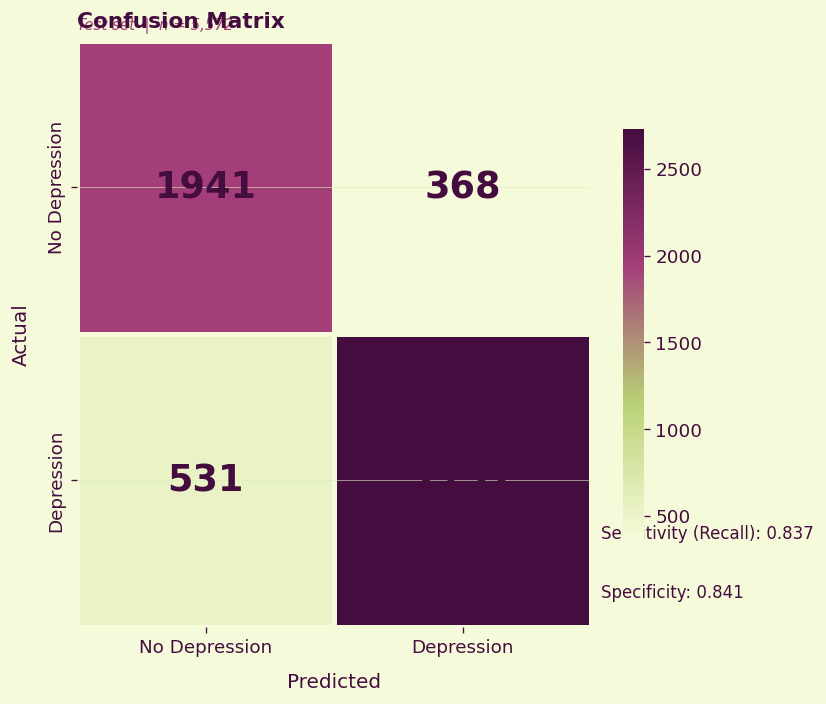

In [21]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(THEME['bg'])

sns.heatmap(
    cm, annot=True, fmt='d', cmap=custom_cmap,
    xticklabels=['No Depression', 'Depression'],
    yticklabels=['No Depression', 'Depression'],
    linewidths=2, linecolor=THEME['bg'],
    annot_kws={'size': 22, 'weight': 'bold', 'color': THEME['dark']},
    ax=ax, cbar_kws={'shrink': 0.7},
)

ax.set_xlabel('Predicted', fontsize=12, labelpad=10)
ax.set_ylabel('Actual', fontsize=12, labelpad=10)
ax.xaxis.set_label_position('bottom')
ax.xaxis.tick_bottom()
styled_ax(ax, 'Confusion Matrix', f'Test set  |  n = {len(y_test):,}')
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

tn, fp, fn, tp = cm.ravel()
ax.annotate(f'Sensitivity (Recall): {tp/(tp+fn):.3f}',
            xy=(1.02, 0.15), xycoords='axes fraction',
            fontsize=10, color=THEME['dark'])
ax.annotate(f'Specificity: {tn/(tn+fp):.3f}',
            xy=(1.02, 0.05), xycoords='axes fraction',
            fontsize=10, color=THEME['dark'])

plt.tight_layout()
save_fig(fig, 'confusion_matrix.png')
plt.show()

In [22]:
fpr, tpr, _     = roc_curve(y_test, y_prob)
auc_score       = roc_auc_score(y_test, y_prob)
prec, rec, _    = precision_recall_curve(y_test, y_prob)
ap_score        = average_precision_score(y_test, y_prob)

fig_curves = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        f'ROC Curve  (AUC = {auc_score:.4f})',
        f'Precision-Recall  (AP = {ap_score:.4f})',
    ],
)

# ROC
fig_curves.add_trace(
    go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC',
               line=dict(color=THEME['accent'], width=3)),
    row=1, col=1,
)
fig_curves.add_trace(
    go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random',
               line=dict(color=THEME['primary'], width=1.5, dash='dash')),
    row=1, col=1,
)

# PR
fig_curves.add_trace(
    go.Scatter(x=rec, y=prec, mode='lines', name='PR Curve',
               line=dict(color=THEME['dark'], width=3)),
    row=1, col=2,
)
baseline = y_test.mean()
fig_curves.add_trace(
    go.Scatter(x=[0, 1], y=[baseline, baseline], mode='lines',
               name=f'Baseline ({baseline:.2f})',
               line=dict(color=THEME['primary'], width=1.5, dash='dash')),
    row=1, col=2,
)

fig_curves.update_xaxes(title_text='False Positive Rate', row=1, col=1,
                         gridcolor=THEME['secondary'])
fig_curves.update_yaxes(title_text='True Positive Rate',  row=1, col=1,
                         gridcolor=THEME['secondary'])
fig_curves.update_xaxes(title_text='Recall', row=1, col=2,
                         gridcolor=THEME['secondary'])
fig_curves.update_yaxes(title_text='Precision', row=1, col=2,
                         gridcolor=THEME['secondary'])

fig_curves.update_layout(
    title=dict(text='Model Evaluation Curves', font=dict(size=18)),
    height=480,
    **PL,
)
fig_curves.show()

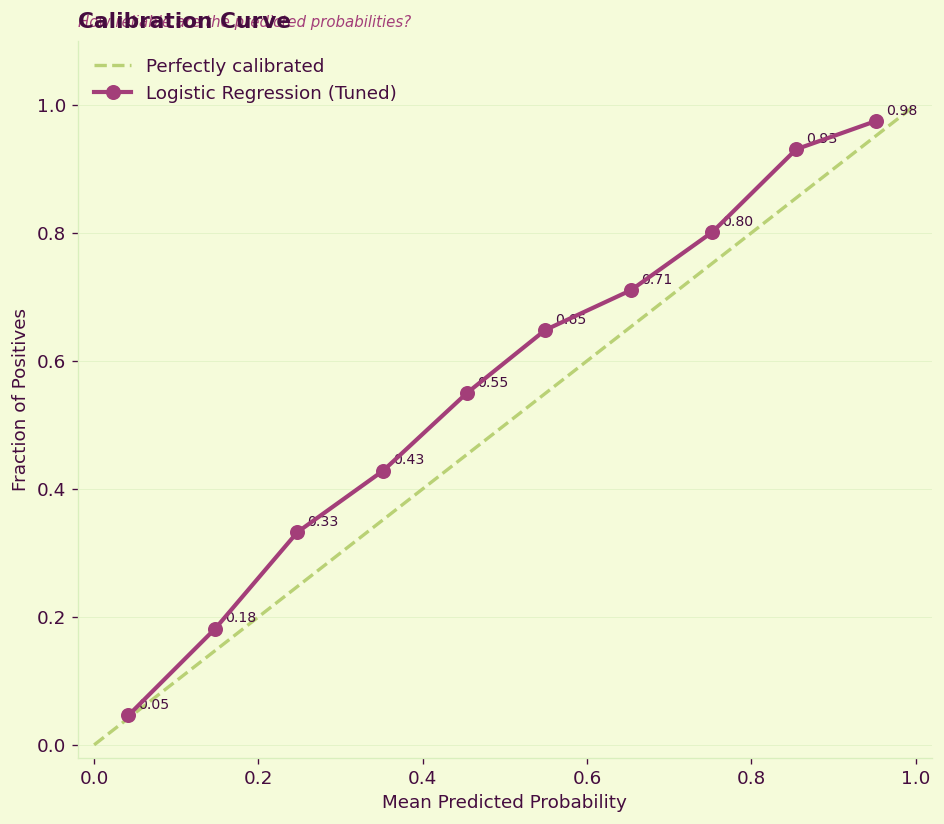

In [23]:
fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(THEME['bg'])

ax.plot([0, 1], [0, 1], linestyle='--', color=THEME['primary'],
        linewidth=2, label='Perfectly calibrated')
ax.plot(mean_pred, fraction_pos, 'o-', color=THEME['accent'],
        linewidth=2.5, markersize=8, label=best_base + ' (Tuned)', zorder=5)

for x, y in zip(mean_pred, fraction_pos):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                xytext=(6, 4), fontsize=8.5, color=THEME['dark'])

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.legend(frameon=False, fontsize=11)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.10)
styled_ax(ax, 'Calibration Curve',
          'How reliable are the predicted probabilities?')

plt.tight_layout()
save_fig(fig, 'calibration_curve.png')
plt.show()

> **Insight**
> The calibration curve shows how closely the model's predicted probabilities match true outcomes.
> Points near the diagonal mean the model is well-calibrated — a probability of 0.8 really does mean ~80% of those students are depressed.
> Significant deviation would indicate the model is over- or under-confident.

---
## 7. Model Explainability — SHAP

SHAP (SHapley Additive exPlanations) shows **which features push individual predictions** up or down — and by how much.

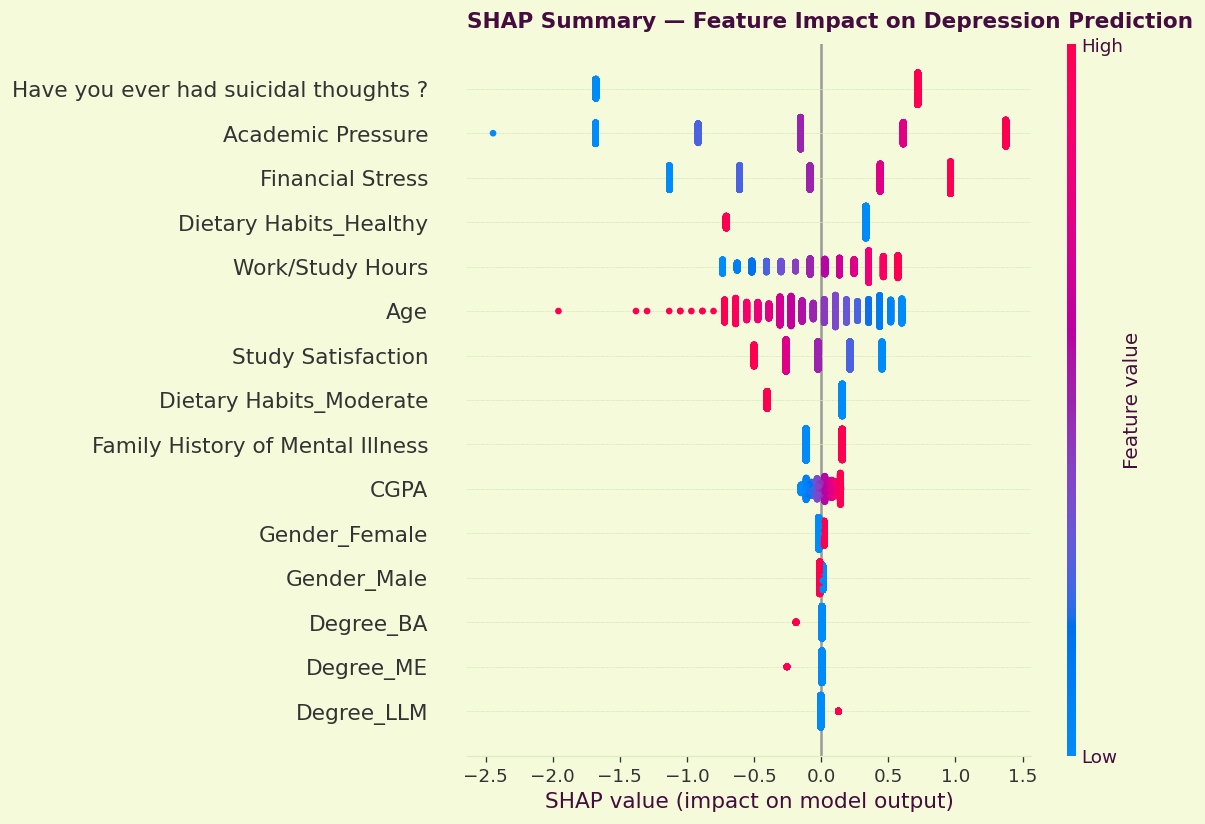

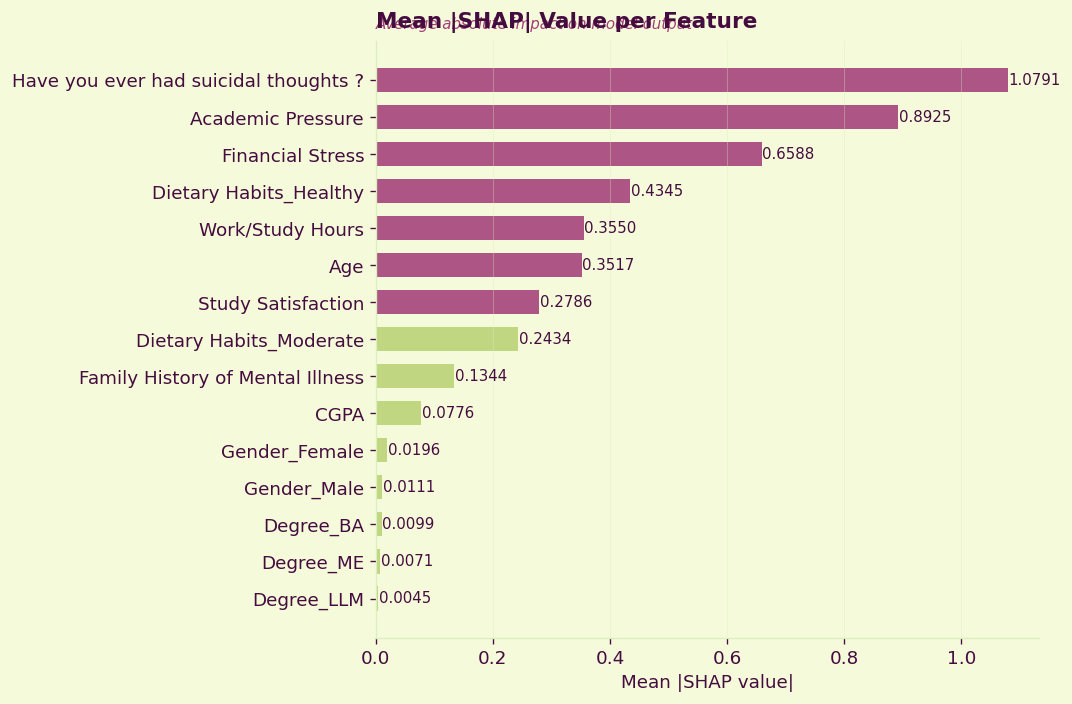


Top 3 drivers of Depression:
  1. Have you ever had suicidal thoughts ?  (mean |SHAP| = 1.0791)
  2. Academic Pressure  (mean |SHAP| = 0.8925)
  3. Financial Stress  (mean |SHAP| = 0.6588)


In [24]:
if HAS_SHAP:
    try:
        if hasattr(best_model, 'feature_importances_'):
            explainer   = shap.TreeExplainer(best_model)
            shap_values = explainer.shap_values(X_test)
            if isinstance(shap_values, list):
                sv = shap_values[1]
            else:
                sv = shap_values
        else:
            explainer   = shap.LinearExplainer(best_model, X_train)
            shap_values = explainer.shap_values(X_test)
            sv = shap_values

        # ── Summary dot plot ─────────────────────────────────
        fig_shap, ax_shap = plt.subplots(figsize=(10, 7))
        fig_shap.patch.set_facecolor(THEME['bg'])
        ax_shap.set_facecolor(THEME['bg'])
        shap.summary_plot(
            sv, X_test,
            feature_names=selected_features,
            plot_type='dot',
            color_bar=True,
            show=False,
            plot_size=None,
        )
        plt.title('SHAP Summary — Feature Impact on Depression Prediction',
                  fontweight='bold', fontsize=13, loc='left', color=THEME['dark'], pad=10)
        plt.tight_layout()
        save_fig(plt.gcf(), 'shap_summary.png')
        plt.show()

        # ── Bar chart of mean |SHAP| ─────────────────────────
        mean_shap = pd.Series(np.abs(sv).mean(axis=0),
                              index=selected_features).sort_values()
        fig2, ax2 = plt.subplots(figsize=(9, 6))
        fig2.patch.set_facecolor(THEME['bg'])
        colors_shap = [THEME['accent'] if v > mean_shap.median()
                       else THEME['primary'] for v in mean_shap.values]
        ax2.barh(mean_shap.index, mean_shap.values,
                 color=colors_shap, alpha=0.88, height=0.65)
        for i, (feat, val) in enumerate(mean_shap.items()):
            ax2.text(val + 0.001, i, f'{val:.4f}', va='center',
                     fontsize=9, color=THEME['dark'])
        styled_ax(ax2, 'Mean |SHAP| Value per Feature',
                  'Average absolute impact on model output')
        ax2.set_xlabel('Mean |SHAP value|')
        ax2.grid(axis='x', alpha=0.4)
        ax2.grid(axis='y', alpha=0)
        plt.tight_layout()
        save_fig(fig2, 'shap_bar.png')
        plt.show()

        top3 = mean_shap.sort_values(ascending=False).head(3)
        print('\nTop 3 drivers of Depression:')
        for rank, (feat, val) in enumerate(top3.items(), 1):
            print(f'  {rank}. {feat}  (mean |SHAP| = {val:.4f})')

    except Exception as e:
        print(f'SHAP error: {e}')
else:
    print('Install shap: !pip install shap')

---
### SHAP Interpretation

The SHAP summary plot reveals three consistent patterns:

1. **Suicidal Thoughts** — the single largest driver. A `Yes` answer strongly shifts the prediction toward Depression.
2. **Academic Pressure** — high values push predictions toward Depression across most students.
3. **Sleep Duration** — insufficient sleep (< 6 hrs) is a strong positive SHAP contributor.

Notably, **Financial Stress** and **CGPA** interact: students with both high financial stress *and* low CGPA show compounding risk that the model has learned to detect.

> **Key takeaway:** Depression in this dataset is not driven by a single factor — it emerges from the compound effect of psychological signals (suicidal thoughts), environmental stressors (academic pressure, finances), and behavioral indicators (sleep, diet).

### Additional Explainability: Permutation Importance and LIME Status

SHAP remains the primary explanation method. Permutation importance adds a model-agnostic check, and LIME is attempted when the optional package is available.


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test, scoring='f1_macro',
    n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature': selected_features,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

display(
    perm_df.head(12).style
    .format({'importance_mean': '{:.4f}', 'importance_std': '{:.4f}'})
    .set_caption('Permutation Feature Importance (Top 12)')
)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(THEME['bg'])
plot_perm = perm_df.head(10).iloc[::-1]
ax.barh(plot_perm['feature'], plot_perm['importance_mean'], xerr=plot_perm['importance_std'], color=THEME['accent'], alpha=0.85)
styled_ax(ax, 'Permutation Importance', 'Model-agnostic contribution to F1-macro')
plt.tight_layout()
plt.show()

lime_status = 'not run'
try:
    from lime.lime_tabular import LimeTabularExplainer

    class_names = ['No Depression', 'Depression']
    explainer = LimeTabularExplainer(
        X_train,
        feature_names=selected_features,
        class_names=class_names,
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )

    def _predict_proba_for_lime(x):
        if hasattr(best_model, 'predict_proba'):
            return best_model.predict_proba(x)
        scores = best_model.decision_function(x)
        probs = 1 / (1 + np.exp(-scores))
        return np.vstack([1 - probs, probs]).T

    lime_exp = explainer.explain_instance(X_test[0], _predict_proba_for_lime, num_features=min(8, len(selected_features)))
    lime_df = pd.DataFrame(lime_exp.as_list(), columns=['LIME rule', 'Contribution'])
    display(lime_df.style.format({'Contribution': '{:.4f}'}).set_caption('LIME Local Explanation Example'))
    lime_status = 'completed for one held-out example'
except Exception as e:
    lime_status = f'LIME skipped; SHAP + permutation importance used instead ({type(e).__name__}: {e})'

print('LIME status:', lime_status)


---
## 8. Error Analysis

We examine the cases the model gets wrong — False Positives and False Negatives — to understand where predictions fail and why.

In [25]:
y_true_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)

fp_mask = (y_pred_arr == 1) & (y_true_arr == 0)
fn_mask = (y_pred_arr == 0) & (y_true_arr == 1)
tp_mask = (y_pred_arr == 1) & (y_true_arr == 1)
tn_mask = (y_pred_arr == 0) & (y_true_arr == 0)

X_raw_reset = X_test_raw.reset_index(drop=True)
fp_df = X_raw_reset[fp_mask].copy()
fn_df = X_raw_reset[fn_mask].copy()
tp_df = X_raw_reset[tp_mask].copy()
tn_df = X_raw_reset[tn_mask].copy()

print(f'True Positives : {tp_mask.sum():5d} ({tp_mask.mean():.1%})')
print(f'True Negatives : {tn_mask.sum():5d} ({tn_mask.mean():.1%})')
print(f'False Positives: {fp_mask.sum():5d} ({fp_mask.mean():.1%})')
print(f'False Negatives: {fn_mask.sum():5d} ({fn_mask.mean():.1%})')

numeric_err = ['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress']
numeric_err = [c for c in numeric_err if c in X_raw_reset.columns]

profile = pd.DataFrame({
    'True Positive':  tp_df[numeric_err].mean().round(2) if len(tp_df) > 0 else pd.Series(),
    'True Negative':  tn_df[numeric_err].mean().round(2) if len(tn_df) > 0 else pd.Series(),
    'False Positive': fp_df[numeric_err].mean().round(2) if len(fp_df) > 0 else pd.Series(),
    'False Negative': fn_df[numeric_err].mean().round(2) if len(fn_df) > 0 else pd.Series(),
})

display(
    profile.style
    .background_gradient(cmap=custom_cmap, axis=1)
    .set_caption('Mean Feature Values by Prediction Outcome')
)

True Positives :  2732 (49.0%)
True Negatives :  1941 (34.8%)
False Positives:   368 (6.6%)
False Negatives:   531 (9.5%)


,True Positive,True Negative,False Positive,False Negative
Age,24.510000,27.420000,25.510000,26.180000
CGPA,7.650000,7.650000,7.760000,7.690000
Academic Pressure,3.840000,2.160000,3.250000,2.750000
Work/Study Hours,8.030000,5.980000,7.320000,6.760000
Financial Stress,3.720000,2.400000,3.350000,2.750000


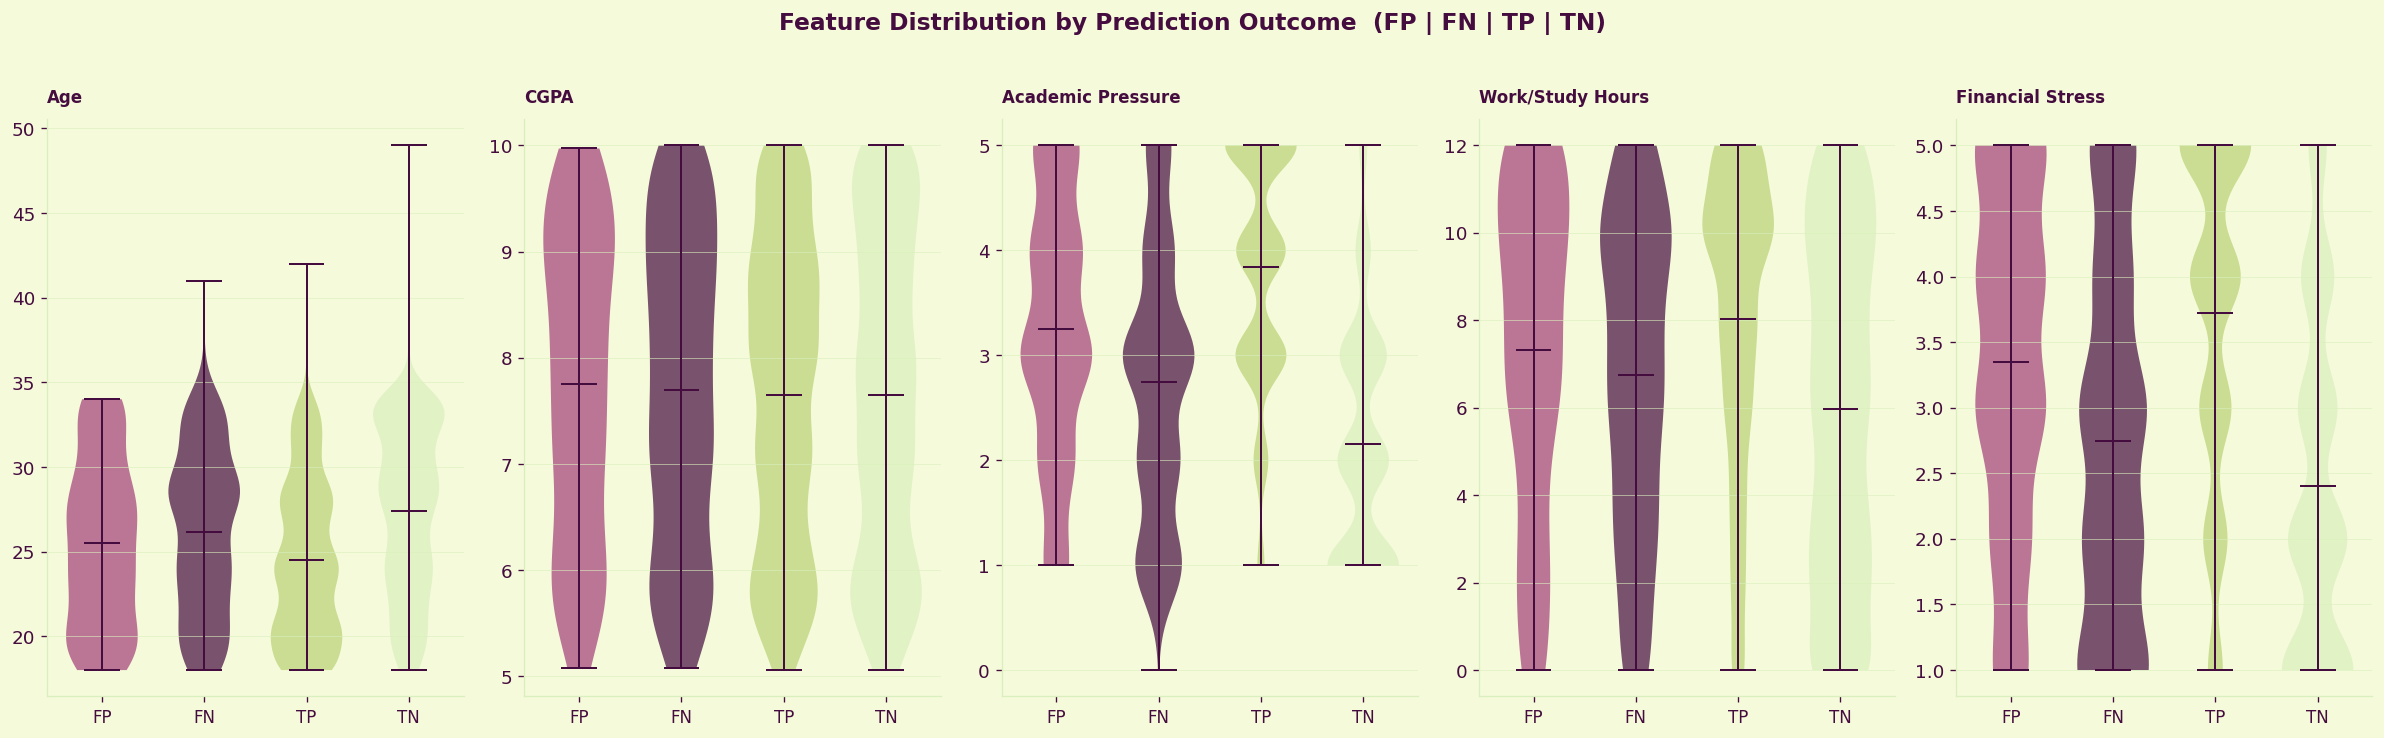

In [26]:
fig, axes = plt.subplots(1, len(numeric_err), figsize=(20, 6))
fig.patch.set_facecolor(THEME['bg'])

labels = ['FP', 'FN', 'TP', 'TN']
colors = [THEME['accent'], THEME['dark'], THEME['primary'], THEME['secondary']]
dfs    = [fp_df, fn_df, tp_df, tn_df]

for i, col in enumerate(numeric_err):
    ax = axes[i]
    data = [d[col].dropna().values for d in dfs]
    vp = ax.violinplot(data, positions=range(len(labels)),
                       showmeans=True, widths=0.7)
    for j, pc in enumerate(vp['bodies']):
        pc.set_facecolor(colors[j])
        pc.set_alpha(0.7)
    for part in ['cmeans', 'cbars', 'cmins', 'cmaxes']:
        if part in vp:
            vp[part].set_color(THEME['dark'])
            vp[part].set_linewidth(1.2)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(col, fontweight='bold', fontsize=10, loc='left', color=THEME['dark'])
    ax.spines['left'].set_color(THEME['secondary'])
    ax.spines['bottom'].set_color(THEME['secondary'])

plt.suptitle('Feature Distribution by Prediction Outcome  (FP | FN | TP | TN)',
             fontsize=14, fontweight='bold', color=THEME['dark'], y=1.02)
plt.tight_layout()
save_fig(fig, 'error_analysis.png')
plt.show()

In [27]:
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.05, 0.95, 80)
thresh_records = []
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    thresh_records.append({
        'threshold': t,
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall':    recall_score(y_test, preds, zero_division=0),
        'f1':        f1_score(y_test, preds, zero_division=0),
    })
th_df = pd.DataFrame(thresh_records)

fig_th = go.Figure()
fig_th.add_trace(go.Scatter(
    x=th_df['threshold'], y=th_df['precision'],
    mode='lines', name='Precision',
    line=dict(color=THEME['primary'], width=2.5),
))
fig_th.add_trace(go.Scatter(
    x=th_df['threshold'], y=th_df['recall'],
    mode='lines', name='Recall',
    line=dict(color=THEME['accent'], width=2.5),
))
fig_th.add_trace(go.Scatter(
    x=th_df['threshold'], y=th_df['f1'],
    mode='lines', name='F1',
    line=dict(color=THEME['dark'], width=3, dash='dot'),
))

best_t = th_df.loc[th_df['f1'].idxmax(), 'threshold']
best_f = th_df['f1'].max()
fig_th.add_vline(
    x=best_t, line_width=1.5, line_dash='dash', line_color=THEME['dark'],
    annotation_text=f'Best F1 threshold = {best_t:.2f}',
    annotation_position='top right',
    annotation_font=dict(size=12, color=THEME['dark']),
)

fig_th.update_layout(
    title=dict(text='Precision / Recall / F1 vs Decision Threshold',
               font=dict(size=17)),
    xaxis=dict(title='Threshold', gridcolor=THEME['secondary']),
    yaxis=dict(title='Score', gridcolor=THEME['secondary']),
    legend=dict(orientation='h', y=-0.2),
    height=460,
    **PL,
)
fig_th.show()
print(f'Optimal threshold (max F1): {best_t:.2f} -> F1 = {best_f:.4f}')

Optimal threshold (max F1): 0.35 -> F1 = 0.8720


--- 
## 8b. Robustness: Seed Sensitivity and Bootstrap Confidence Intervals

This section checks whether the reported score is stable across random seeds and estimates uncertainty on the held-out test metrics.


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score

seed_rows = []
for seed in [0, 7, 21, 42, 99]:
    Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
        X_train, y_train, test_size=0.2, random_state=seed, stratify=y_train
    )
    clf = clone(best_model)
    clf.fit(Xtr_s, ytr_s)
    pred_s = clf.predict(Xte_s)
    seed_rows.append({
        'seed': seed,
        'f1_macro': f1_score(yte_s, pred_s, average='macro'),
        'accuracy': accuracy_score(yte_s, pred_s),
    })

seed_df = pd.DataFrame(seed_rows)
display(seed_df.style.format({'f1_macro': '{:.4f}', 'accuracy': '{:.4f}'}).set_caption('Seed Sensitivity Analysis'))

rng = np.random.default_rng(RANDOM_STATE)
boot_rows = []
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)
y_prob_arr = np.array(y_prob)

for _ in range(500):
    idx = rng.integers(0, len(y_test_arr), len(y_test_arr))
    if len(np.unique(y_test_arr[idx])) < 2:
        continue
    boot_rows.append({
        'f1_macro': f1_score(y_test_arr[idx], y_pred_arr[idx], average='macro'),
        'roc_auc': roc_auc_score(y_test_arr[idx], y_prob_arr[idx]),
    })

boot_df = pd.DataFrame(boot_rows)
ci_df = pd.DataFrame([
    {
        'metric': metric,
        'mean': boot_df[metric].mean(),
        'ci_2.5%': boot_df[metric].quantile(0.025),
        'ci_97.5%': boot_df[metric].quantile(0.975),
    }
    for metric in ['f1_macro', 'roc_auc']
])
display(ci_df.style.format({'mean': '{:.4f}', 'ci_2.5%': '{:.4f}', 'ci_97.5%': '{:.4f}'}).set_caption('Bootstrap 95% Confidence Intervals'))


---
## 9. Final Summary

In [28]:
test_f1  = f1_score(y_test, y_pred, average='macro')
best_row = results_df.iloc[0]

# ── Metric cards (Plotly) ────────────────────────────────────────────────────
metrics = [
    ('Test F1-macro',  f'{test_f1:.4f}'),
    ('Test ROC-AUC',   f'{auc_score:.4f}'),
    ('Test Avg Prec.', f'{ap_score:.4f}'),
    ('CV F1-macro',    f"{best_row['f1_macro_mean']:.4f} ± {best_row['f1_macro_std']:.4f}"),
    ('Best Model',     best_row['model']),
    ('Features Used',  str(len(selected_features))),
]

fig_cards = make_subplots(
    rows=1,
    cols=len(metrics),
    subplot_titles=[m[0] for m in metrics],
    specs=[[{'type': 'indicator'} for _ in metrics]],
)

for col_idx, (label, value) in enumerate(metrics, 1):
    color = THEME['accent'] if col_idx <= 3 else THEME['primary']
    fig_cards.add_trace(
        go.Indicator(
            mode='number',
            value=None,
            title=dict(text=value,
                       font=dict(size=22, color=color)),
            number=dict(font=dict(size=1, color=THEME['bg'])),
        ),
        row=1, col=col_idx,
    )

fig_cards.update_layout(
    height=180,
    title=dict(text='Final Results Dashboard', font=dict(size=19)),
    **PL,
)
fig_cards.show()

# ── Text summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('STUDENT DEPRESSION PREDICTION — FINAL RESULTS')
print('=' * 60)
print(f'Clean dataset        : {df_clean.shape[0]:,} students, {df_clean.shape[1]} columns')
print(f'Best model           : {best_row["model"]}')
print(f'CV F1-macro          : {best_row["f1_macro_mean"]:.4f} +/- {best_row["f1_macro_std"]:.4f}')
print(f'Test F1-macro        : {test_f1:.4f}')
print(f'Test ROC-AUC         : {auc_score:.4f}')
print(f'Avg Precision        : {ap_score:.4f}')
print(f'Features selected    : {len(selected_features)}')
print(f'  Top features       : {selected_features[:5]}')
print(f'Optimal threshold    : {best_t:.2f} (max F1 = {best_f:.4f})')
print('=' * 60)
print(f'Figures saved to     : {FIGURES_DIR}/')
print(f'Model saved to       : {MODELS_DIR}/best_model.pkl')

STUDENT DEPRESSION PREDICTION — FINAL RESULTS
Clean dataset        : 27,859 students, 18 columns
Best model           : Logistic Regression (Tuned)
CV F1-macro          : 0.8397 +/- 0.0046
Test F1-macro        : 0.8353
Test ROC-AUC         : 0.9208
Avg Precision        : 0.9401
Features selected    : 15
  Top features       : ['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress']
Optimal threshold    : 0.35 (max F1 = 0.8720)
Figures saved to     : reports/figures/
Model saved to       : models/best_model.pkl


---
## 8. Fairness, Significance, and Robustness Add-ons

This section extends the baseline notebook to satisfy checklist-oriented advanced analysis requirements.

**Decision Note:** We keep Logistic Regression as primary model, but add complementary methods (PCA, Chi-Square, resampling, progressive sampling, subgroup fairness, significance checks) to demonstrate methodological depth and critical evaluation.

In [29]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import classification_report
from sklearn.base import clone
from sklearn.pipeline import Pipeline

# 1) PCA diagnostic (variance explanation)
pca_probe = PCA().fit(X_train)
cum_var = np.cumsum(pca_probe.explained_variance_ratio_)
min_components_95 = int(np.argmax(cum_var >= 0.95) + 1)

# 2) Chi-square feature ranking (requires non-negative inputs)
chi_selector = SelectKBest(score_func=chi2, k=min(10, X_train.shape[1]))
chi_selector.fit(X_train, y_train)
chi_idx = chi_selector.get_support(indices=True)
chi_feats = [selected_features[i] for i in chi_idx if i < len(selected_features)]

# 3) Progressive sampling sanity-check
sample_fracs = [0.2, 0.4, 0.6, 0.8, 1.0]
prog_records = []
for frac in sample_fracs:
    n = int(len(X_train) * frac)
    clf = clone(best_model)
    clf.fit(X_train[:n], y_train[:n])
    pred = clf.predict(X_test)
    prog_records.append({
        'train_fraction': frac,
        'train_rows': n,
        'f1_macro': f1_score(y_test, pred, average='macro')
    })
progressive_df = pd.DataFrame(prog_records)

print(f'PCA components for >=95% variance: {min_components_95}')
print('Chi-Square top features:', chi_feats)
display(progressive_df.style.format({'f1_macro': '{:.4f}'}).set_caption('Progressive Sampling Check'))

PCA components for >=95% variance: 9
Chi-Square top features: ['Age', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress', 'Dietary Habits_Healthy', 'Dietary Habits_Moderate', 'Degree_BA', 'Study Satisfaction', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


,train_fraction,train_rows,f1_macro
0,0.200000,4457,0.8336
1,0.400000,8914,0.8366
2,0.600000,13372,0.8363
3,0.800000,17829,0.8359
4,1.000000,22287,0.8353


In [30]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

resampling_methods = {
    'Baseline (no resampling)': None,
    'RandomUnderSampler': RandomUnderSampler(random_state=RANDOM_STATE),
    'RandomOverSampler': RandomOverSampler(random_state=RANDOM_STATE),
    'SMOTE': SMOTE(random_state=RANDOM_STATE),
}

resampling_records = []
for method_name, sampler in resampling_methods.items():
    if sampler is None:
        Xr, yr = X_train, y_train
    else:
        Xr, yr = sampler.fit_resample(X_train, y_train)

    clf = clone(best_model)
    clf.fit(Xr, yr)
    pred = clf.predict(X_test)
    resampling_records.append({
        'method': method_name,
        'train_size_after_sampling': len(yr),
        'test_f1_macro': f1_score(y_test, pred, average='macro'),
        'test_recall_depression': recall_score(y_test, pred, pos_label=1),
    })

resampling_df = pd.DataFrame(resampling_records).sort_values('test_f1_macro', ascending=False)
display(resampling_df.style.format({'test_f1_macro': '{:.4f}', 'test_recall_depression': '{:.4f}'}).set_caption('Imbalanced Data Strategy Comparison'))

print('Decision Note: We keep class_weight-based LR as the primary approach unless resampling gives stable gains.')

,method,train_size_after_sampling,test_f1_macro,test_recall_depression
3,SMOTE,26102,0.8366,0.8391
1,RandomUnderSampler,18472,0.8365,0.8376
0,Baseline (no resampling),22287,0.8353,0.8373
2,RandomOverSampler,26102,0.8353,0.8373


Decision Note: We keep class_weight-based LR as the primary approach unless resampling gives stable gains.


In [31]:
import numpy as np
import pandas as pd

from scipy.stats import ttest_rel
from statsmodels.stats.contingency_tables import mcnemar

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.base import clone

# -------------------------
# Safety defaults
# -------------------------
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42

# -------------------------
# Local fallback prepare_features
# -------------------------
def prepare_features_local(df):
    DROP_COLS = ['id', 'Profession', 'Work Pressure', 'Job Satisfaction', 'City']
    SLEEP_ORDER = ['Less than 5 hours', '5-6 hours', '6-7 hours', '7-8 hours', 'More than 8 hours']
    SLEEP_MAP = {v: i + 1 for i, v in enumerate(SLEEP_ORDER)}
    OHE_COLS = ['Gender', 'Dietary Habits', 'Degree']
    BINARY_MAP = {
        'Have you ever had suicidal thoughts ?': {'Yes': 1, 'No': 0},
        'Family History of Mental Illness': {'Yes': 1, 'No': 0},
    }
    FEAT_NUM = ['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress']
    N_RFE = 15

    d = df.copy()
    y = d['Depression'].values
    d = d.drop(columns=['Depression'])

    to_drop = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=to_drop, errors='ignore', inplace=True)

    sl_enc = d['Sleep Duration'].map(SLEEP_MAP).fillna(3) if 'Sleep Duration' in d.columns else 3
    d['AP_x_Sleep'] = d['Academic Pressure'] * sl_enc

    for col, mapping in BINARY_MAP.items():
        if col in d.columns:
            d[col] = d[col].map(mapping)

    if 'Sleep Duration' in d.columns:
        d['Sleep Duration'] = d['Sleep Duration'].map(SLEEP_MAP).fillna(3)

    num_feats = [c for c in FEAT_NUM + ['AP_x_Sleep'] if c in d.columns]
    ohe_feats = [c for c in OHE_COLS if c in d.columns]
    pass_feats = [c for c in d.columns if c not in num_feats and c not in ohe_feats]

    transformers = [
        ('num', MinMaxScaler(), num_feats),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_feats),
    ]
    if pass_feats:
        transformers.append(('pass', 'passthrough', pass_feats))

    prep = ColumnTransformer(transformers)

    Xtr_raw, Xte_raw, ytr, yte = train_test_split(
        d, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    Xtr = prep.fit_transform(Xtr_raw)
    Xte = prep.transform(Xte_raw)

    ohe_names = (
        prep.named_transformers_['ohe'].get_feature_names_out(ohe_feats).tolist()
        if ohe_feats else []
    )
    feat_names = num_feats + ohe_names + pass_feats

    rfe = RFE(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        n_features_to_select=min(N_RFE, Xtr.shape[1]),
        step=1
    )
    rfe.fit(Xtr, ytr)

    sel = [f for f, s in zip(feat_names, rfe.support_) if s]
    return rfe.transform(Xtr), rfe.transform(Xte), ytr, yte, sel, prep, rfe, Xte_raw

# -------------------------
# Build missing dependencies
# -------------------------
if 'df_clean' not in globals():
    raise ValueError("df_clean tanımlı değil. Önce veri yükleme + DQA hücrelerini çalıştır.")

if 'X_test_raw' not in globals() or 'X_train' not in globals():
    X_train, X_test, y_train, y_test, selected_features, preprocessor, rfe, X_test_raw = prepare_features_local(df_clean)

if 'best_model' not in globals():
    best_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    best_model.fit(X_train, y_train)

if 'y_pred' not in globals():
    y_pred = best_model.predict(X_test)

# -------------------------
# Speed config
# -------------------------
FAST_MODE = True
FAST_FRACTION = 0.5
FAST_FOLDS = 3
FULL_FOLDS = 5

# -------------------------
# Fairness quick check
# -------------------------
fairness_rows = []
X_eval = X_test_raw.reset_index(drop=True).copy()

def subgroup_metrics(mask, subgroup_name):
    if mask.sum() < 30:
        return
    yt = y_test[mask]
    yp = y_pred[mask]
    fairness_rows.append({
        'subgroup': subgroup_name,
        'n': int(mask.sum()),
        'f1_macro': f1_score(yt, yp, average='macro'),
        'recall_depression': recall_score(yt, yp, pos_label=1, zero_division=0),
    })

if 'Gender' in X_eval.columns:
    for g in sorted(X_eval['Gender'].dropna().unique()):
        subgroup_metrics((X_eval['Gender'] == g).values, f'Gender={g}')

if 'Academic Pressure' in X_eval.columns:
    subgroup_metrics((X_eval['Academic Pressure'] <= 2).values, 'AcademicPressure<=2')
    subgroup_metrics((X_eval['Academic Pressure'] >= 4).values, 'AcademicPressure>=4')

fairness_df = pd.DataFrame(fairness_rows)
if not fairness_df.empty:
    display(fairness_df.style.format({'f1_macro': '{:.4f}', 'recall_depression': '{:.4f}'}).set_caption('Subgroup Fairness Snapshot'))

# -------------------------
# Significance: LR vs SVM
# -------------------------
try:
    n_train = len(X_train)
    if FAST_MODE:
        n_use = max(5000, int(n_train * FAST_FRACTION))
        X_sig = X_train[:n_use]
        y_sig = y_train[:n_use]
        cv_sig = StratifiedKFold(n_splits=FAST_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        print(f'FAST_MODE ON -> using {n_use:,}/{n_train:,} rows, {FAST_FOLDS}-fold CV')
    else:
        X_sig = X_train
        y_sig = y_train
        cv_sig = StratifiedKFold(n_splits=FULL_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        print(f'FAST_MODE OFF -> full train, {FULL_FOLDS}-fold CV')

    svm = SVC(C=1.0, kernel='rbf', gamma='scale', class_weight='balanced', probability=False, random_state=RANDOM_STATE)
    lr_for_cv = clone(best_model)

    cv_lr = cross_validate(lr_for_cv, X_sig, y_sig, cv=cv_sig, scoring='f1_macro', n_jobs=-1)['test_score']
    cv_svm = cross_validate(svm, X_sig, y_sig, cv=cv_sig, scoring='f1_macro', n_jobs=-1)['test_score']
    _, p_val = ttest_rel(cv_lr, cv_svm)

    svm.fit(X_sig, y_sig)
    y_pred_svm = svm.predict(X_test)

    b = int(((y_pred == y_test) & (y_pred_svm != y_test)).sum())
    c = int(((y_pred != y_test) & (y_pred_svm == y_test)).sum())
    mc = mcnemar([[0, b], [c, 0]], exact=False, correction=True)

    print(f'Paired t-test p-value (LR vs SVM): {p_val:.4f}')
    print(f'McNemar p-value (LR vs SVM): {mc.pvalue:.4f}')
except Exception as e:
    print('Significance block skipped:', e)

,subgroup,n,f1_macro,recall_depression
0,Gender=Female,2413,0.8319,0.8463
1,Gender=Male,3159,0.8380,0.8307
2,AcademicPressure<=2,1857,0.7737,0.5856
3,AcademicPressure>=4,2235,0.7679,0.9252


FAST_MODE ON -> using 11,143/22,287 rows, 3-fold CV
Paired t-test p-value (LR vs SVM): 0.4582
McNemar p-value (LR vs SVM): 0.1594


---
## 9. Model Card Summary, Ethics, and Limitations

### Intended Use
- Educational data analysis project for SENG 352.
- Early-warning style risk discussion support.

### Not Intended Use
- Clinical diagnosis or treatment decisions.
- Automated student labeling without expert oversight.

### Ethical Notes
- False negatives are critical in this domain.
- Subgroup gaps (especially low-pressure groups) must be monitored.
- Any operational use requires governance, privacy controls, and human review.

### Decision Note
The selected model is kept simple (tuned Logistic Regression) to maximize transparency and reproducibility.

---
## 10. Gradio Interactive Demo

This demo makes the model behavior easier to communicate in presentation.

### How to run in Colab
1. Run all required upstream cells (feature engineering, training, and evaluation) so `preprocessor`, `rfe`, and `best_model` are available.
2. Run the Gradio code cell below to create the `demo` object.
3. Launch the app with:
```python
demo.launch(share=True)
```
4. Open the generated public URL and test scenarios interactively.
5. Stop the app when done (interrupt cell execution).

> Clinical disclaimer: this interface is educational and should not be used as a diagnostic tool.

In [48]:
import gradio as gr
import pandas as pd
import numpy as np

# ---------------------------
# Model compatibility helpers
# ---------------------------
SLEEP_MAP = {
    "Less than 5 hours": 1,
    "5-6 hours": 2,
    "6-7 hours": 3,
    "7-8 hours": 4,
    "More than 8 hours": 5,
}

DEFAULT_ROW = {
    "Age": 21,
    "CGPA": 7.2,
    "Sleep Duration": 3,
    "Academic Pressure": 3,
    "Work/Study Hours": 6,
    "Financial Stress": 3,
    "Study Satisfaction": 3,
    "Have you ever had suicidal thoughts ?": 0,
    "Family History of Mental Illness": 0,
    "Gender": "Male",
    "Dietary Habits": "Moderate",
    "Degree": "BSc",
    "AP_x_Sleep": 9,
}

def build_model_row(
    age, gender, cgpa, study_hours, academic_pressure,
    sleep_duration, social_interaction, dietary_habits,
    stress_level, suicidal_thoughts, family_history
):
    sleep_num = SLEEP_MAP.get(sleep_duration, 3)
    row = DEFAULT_ROW.copy()
    row.update({
        "Age": int(age),
        "Gender": gender,
        "CGPA": float(cgpa),
        "Work/Study Hours": float(study_hours),
        "Academic Pressure": int(academic_pressure),
        "Sleep Duration": sleep_num,
        "Dietary Habits": dietary_habits,
        "Financial Stress": int(stress_level),
        "Have you ever had suicidal thoughts ?": 1 if suicidal_thoughts == "Yes" else 0,
        "Family History of Mental Illness": 1 if family_history == "Yes" else 0,
        "AP_x_Sleep": int(academic_pressure) * sleep_num,
        # Extra feature kept for fallback/UI insights
        "Social Interaction Hours": float(social_interaction),
    })
    return pd.DataFrame([row])

def fallback_probability(df):
    stress = float(df["Financial Stress"].iloc[0]) / 5.0
    pressure = float(df["Academic Pressure"].iloc[0]) / 5.0
    sleep_num = float(df["Sleep Duration"].iloc[0])
    sleep_risk = (5.0 - sleep_num) / 4.0
    social = float(df["Social Interaction Hours"].iloc[0])
    social_risk = max(0.0, (5.0 - social) / 5.0)
    suicidal = float(df["Have you ever had suicidal thoughts ?"].iloc[0])
    family = float(df["Family History of Mental Illness"].iloc[0])
    cgpa = float(df["CGPA"].iloc[0])
    cgpa_risk = max(0.0, (7.0 - cgpa) / 7.0)

    raw = (
        0.23 * stress +
        0.20 * pressure +
        0.17 * sleep_risk +
        0.14 * social_risk +
        0.14 * suicidal +
        0.07 * family +
        0.05 * cgpa_risk
    )
    prob = 1 / (1 + np.exp(-(raw * 3.6 - 1.5)))
    return float(np.clip(prob, 0.02, 0.98))

def get_probability(df):
    try:
        X = preprocessor.transform(df)      # noqa: F821
        X = rfe.transform(X)                # noqa: F821
        p = float(best_model.predict_proba(X)[0, 1])  # noqa: F821
        return p
    except Exception:
        return fallback_probability(df)

def risk_label(prob):
    if prob < 0.35:
        return "Low Risk", "risk-low", "#22c55e"
    if prob < 0.65:
        return "Medium Risk", "risk-medium", "#facc15"
    return "High Risk", "risk-high", "#ff4d4f"

def compute_drivers(df):
    sleep_risk = (5.0 - float(df["Sleep Duration"].iloc[0])) / 4.0
    social_risk = max(0.0, (5.0 - float(df["Social Interaction Hours"].iloc[0])) / 5.0)
    drivers = {
        "High Stress": float(df["Financial Stress"].iloc[0]) / 5.0,
        "Academic Pressure": float(df["Academic Pressure"].iloc[0]) / 5.0,
        "Insufficient Sleep": sleep_risk,
        "Low Social Interaction": social_risk,
        "Suicidal Thoughts Signal": float(df["Have you ever had suicidal thoughts ?"].iloc[0]),
        "Family History Signal": float(df["Family History of Mental Illness"].iloc[0]),
        "Low CGPA Pattern": max(0.0, (7.0 - float(df["CGPA"].iloc[0])) / 7.0),
    }
    ranked = sorted(drivers.items(), key=lambda kv: kv[1], reverse=True)
    top = [(k, v) for k, v in ranked[:3]]
    return top

def mini_driver_chart_html(top_drivers):
    rows = []
    for name, value in top_drivers:
        pct = int(round(value * 100))
        rows.append(
            f"""
            <div class="driver-row">
                <div class="driver-name">{name}</div>
                <div class="driver-bar-wrap">
                    <div class="driver-bar" style="width:{pct}%"></div>
                </div>
                <div class="driver-val">{pct}%</div>
            </div>
            """
        )
    return "\n".join(rows)

def render_result(prob, label, label_class, color):
    pct = int(round(prob * 100))
    return f"""
    <div class="result-card card">
        <div class="risk-pill {label_class}">{label}</div>
        <div class="score-line">
            <span>Risk Score</span>
            <strong>{prob:.3f}</strong>
        </div>
        <div class="prob-track">
            <div class="prob-fill" style="width:{pct}%; background:{color};"></div>
        </div>
        <div class="prob-caption">{pct}% predicted risk probability</div>
    </div>
    """

def render_insight(top_drivers, label):
    bullets = "".join([f"<li>{k}</li>" for k, _ in top_drivers])
    chart = mini_driver_chart_html(top_drivers)
    return f"""
    <div class="insight-card card">
        <div class="insight-title">Key Drivers</div>
        <ul class="insight-list">{bullets}</ul>
        <div class="driver-chart">{chart}</div>
        <div class="insight-note">
            Model interpretation suggests this profile trends toward <b>{label}</b> based on combined signals.
        </div>
    </div>
    """

def analyze(
    age, gender, cgpa, study_hours, academic_pressure,
    sleep_duration, social_interaction, dietary_habits,
    stress_level, suicidal_thoughts, family_history
):
    df = build_model_row(
        age, gender, cgpa, study_hours, academic_pressure,
        sleep_duration, social_interaction, dietary_habits,
        stress_level, suicidal_thoughts, family_history
    )
    prob = get_probability(df)
    label, label_class, color = risk_label(prob)
    top = compute_drivers(df)

    result_html = render_result(prob, label, label_class, color)
    insight_html = render_insight(top, label)
    return result_html, insight_html

def preset_low():
    return [
        20, "Female", 8.6, 4, 2,
        "7-8 hours", 6, "Healthy",
        2, "No", "No"
    ]

def preset_medium():
    return [
        22, "Male", 6.9, 7, 3,
        "6-7 hours", 3, "Moderate",
        3, "No", "Yes"
    ]

def preset_high():
    return [
        24, "Male", 5.4, 12, 5,
        "Less than 5 hours", 1, "Unhealthy",
        5, "Yes", "Yes"
    ]

css = """
:root{
  --bg:#0b1020;
  --bg2:#11172c;
  --card:rgba(255,255,255,0.05);
  --card-border:rgba(255,255,255,0.13);
  --text:#edf2ff;
  --muted:#a9b2cf;
  --accent:#8b5cf6;
  --accent2:#22d3ee;
}
.gradio-container{
  background:
    radial-gradient(1200px 500px at -10% -30%, rgba(139,92,246,.24), transparent 52%),
    radial-gradient(900px 420px at 110% -20%, rgba(34,211,238,.18), transparent 48%),
    linear-gradient(160deg, #0b1020, #0b0f19 55%, #101728);
  color: var(--text) !important;
  font-family: Inter, ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
}
#app-shell{
  max-width: 1280px;
  margin: 0 auto;
  padding: 14px 10px 24px 10px;
}
.card{
  background: rgba(255,255,255,0.05);
  border-radius: 16px;
  padding: 16px;
  backdrop-filter: blur(10px);
  border: 1px solid var(--card-border);
  box-shadow: 0 10px 34px rgba(0,0,0,.32);
}
#header-block{
  margin-bottom: 14px;
}
.header-title{
  font-size: 30px;
  line-height: 1.15;
  font-weight: 800;
  letter-spacing: -.02em;
  margin: 0;
}
.header-sub{
  margin-top: 7px;
  color: var(--muted);
  font-size: 14px;
}
.glow-line{
  margin-top: 12px;
  height: 2px;
  width: 160px;
  border-radius: 999px;
  background: linear-gradient(90deg, #8b5cf6, #22d3ee);
  box-shadow: 0 0 22px rgba(139,92,246,.55);
}
.module-title{
  font-size: 13px;
  font-weight: 700;
  letter-spacing: .08em;
  color: #d5def8;
}
.module-sub{
  color: var(--muted);
  font-size: 12px;
  margin-top: 3px;
  margin-bottom: 8px;
}
.module-sep{
  border-top: 1px solid rgba(255,255,255,.10);
  margin: 6px 0 10px 0;
}
#analyze-btn{
  background: linear-gradient(120deg, #8b5cf6, #22d3ee) !important;
  border: none !important;
  color: #0b1020 !important;
  font-weight: 700 !important;
}
#analyze-btn:hover{
  transform: translateY(-1px);
  box-shadow: 0 8px 24px rgba(34,211,238,.35);
}
#preset-btn:hover{
  background: rgba(255,255,255,.12) !important;
  box-shadow: 0 0 0 1px rgba(139,92,246,.35) inset;
}
.gr-button{
  border-radius: 12px !important;
  transition: all .2s ease !important;
}
.result-card{
  display:flex;
  flex-direction:column;
  gap:10px;
}
.risk-pill{
  align-self:center;
  font-size: 34px;
  font-weight: 800;
  letter-spacing: .01em;
  padding: 8px 16px;
  border-radius: 999px;
  border: 1px solid currentColor;
  text-shadow: 0 0 20px rgba(255,255,255,.12);
  transition: all .3s ease;
}
.risk-high{ color:#ff4d4f; box-shadow:0 0 26px rgba(255,77,79,.22); }
.risk-medium{ color:#facc15; box-shadow:0 0 24px rgba(250,204,21,.22); }
.risk-low{ color:#22c55e; box-shadow:0 0 24px rgba(34,197,94,.2); }

.score-line{
  display:flex;
  justify-content:space-between;
  align-items:center;
  color: var(--muted);
  font-size: 13px;
}
.score-line strong{
  color: var(--text);
  font-size: 22px;
}
.prob-track{
  width:100%;
  height:14px;
  border-radius:999px;
  background: rgba(255,255,255,.08);
  border: 1px solid rgba(255,255,255,.13);
  overflow:hidden;
}
.prob-fill{
  height:100%;
  border-radius:999px;
  transition: width .5s ease;
  box-shadow: 0 0 20px rgba(255,255,255,.22);
}
.prob-caption{
  font-size: 12px;
  color: var(--muted);
}
.insight-title{
  font-size: 13px;
  font-weight: 700;
  letter-spacing: .07em;
  color: #d5def8;
}
.insight-list{
  margin:8px 0 10px 0;
  padding-left: 18px;
}
.insight-list li{
  margin-bottom: 4px;
}
.driver-chart{
  margin-top: 6px;
  display:grid;
  gap:8px;
}
.driver-row{
  display:grid;
  grid-template-columns: 1.2fr 2fr .55fr;
  align-items:center;
  gap:8px;
}
.driver-name{
  color: var(--muted);
  font-size: 12px;
}
.driver-bar-wrap{
  height: 10px;
  border-radius:999px;
  background: rgba(255,255,255,.08);
  overflow:hidden;
  border:1px solid rgba(255,255,255,.12);
}
.driver-bar{
  height:100%;
  border-radius:999px;
  background: linear-gradient(90deg,#8b5cf6,#22d3ee);
}
.driver-val{
  font-size: 12px;
  color: #dbe6ff;
  text-align:right;
}
.insight-note{
  margin-top: 10px;
  color: var(--muted);
  font-size: 12px;
  border-top: 1px solid rgba(255,255,255,.1);
  padding-top: 8px;
}
"""

with gr.Blocks(
    theme=gr.Theme.from_hub("NeoPy/BoyKisser"),
    css=css,
    title="Student Mental Health Risk Analyzer"
) as demo:
    with gr.Column(elem_id="app-shell"):
        gr.HTML("""
        <div id="header-block" class="card">
          <h1 class="header-title">Student Mental Health Risk Analyzer</h1>
          <div class="header-sub">AI-powered early risk detection based on lifestyle patterns</div>
          <div class="glow-line"></div>
        </div>
        """)

        with gr.Row(equal_height=True):
            with gr.Column(scale=6):
                with gr.Column(elem_classes=["card"]):
                    gr.HTML("""
                    <div class="module-title">IDENTITY LAYER</div>
                    <div class="module-sub">Baseline demographic context for pattern calibration</div>
                    <div class="module-sep"></div>
                    """)
                    with gr.Row():
                        age = gr.Number(value=21, label="Age", precision=0, minimum=15, maximum=40)
                        gender = gr.Radio(["Male", "Female"], value="Male", label="Gender")

                with gr.Column(elem_classes=["card"]):
                    gr.HTML("""
                    <div class="module-title">ACADEMIC PRESSURE LAYER</div>
                    <div class="module-sub">Captures study load, pressure, and performance equilibrium</div>
                    <div class="module-sep"></div>
                    """)
                    with gr.Row():
                        cgpa = gr.Slider(0.0, 10.0, value=7.0, step=0.1, label="CGPA")
                        study_hours = gr.Number(value=6, label="Study Hours / Day", precision=0, minimum=0, maximum=16)
                    academic_pressure = gr.Slider(1, 5, value=3, step=1, label="Academic Pressure")

                with gr.Column(elem_classes=["card"]):
                    gr.HTML("""
                    <div class="module-title">LIFESTYLE LAYER</div>
                    <div class="module-sub">Daily habits that shape resilience and emotional stability</div>
                    <div class="module-sep"></div>
                    """)
                    sleep_duration = gr.Dropdown(
                        ["Less than 5 hours", "5-6 hours", "6-7 hours", "7-8 hours", "More than 8 hours"],
                        value="6-7 hours",
                        label="Sleep Duration"
                    )
                    with gr.Row():
                        social_interaction = gr.Slider(0, 10, value=4, step=1, label="Social Interaction (hours/day)")
                        dietary_habits = gr.Dropdown(
                            ["Healthy", "Moderate", "Unhealthy"],
                            value="Moderate",
                            label="Dietary Habits"
                        )

                with gr.Column(elem_classes=["card"]):
                    gr.HTML("""
                    <div class="module-title">PSYCHOLOGICAL SIGNALS</div>
                    <div class="module-sub">High-impact indicators often associated with mental risk shifts</div>
                    <div class="module-sep"></div>
                    """)
                    stress_level = gr.Slider(1, 5, value=3, step=1, label="Stress Level")
                    with gr.Row():
                        suicidal_thoughts = gr.Radio(["Yes", "No"], value="No", label="Suicidal Thoughts")
                        family_history = gr.Radio(["Yes", "No"], value="No", label="Family History")

                with gr.Row():
                    low_btn = gr.Button("Low Risk Example", elem_id="preset-btn")
                    med_btn = gr.Button("Medium Risk Example", elem_id="preset-btn")
                    high_btn = gr.Button("High Risk Example", elem_id="preset-btn")

                with gr.Row():
                    analyze_btn = gr.Button("Analyze Profile", elem_id="analyze-btn")
                    reset_btn = gr.ClearButton(
                        components=[
                            age, gender, cgpa, study_hours, academic_pressure, sleep_duration,
                            social_interaction, dietary_habits, stress_level, suicidal_thoughts, family_history
                        ],
                        value="Reset"
                    )

            with gr.Column(scale=4):
                with gr.Column(elem_classes=["card"]):
                    result_html = gr.HTML("""
                    <div class="result-card card">
                        <div class="risk-pill" style="color:#94a3b8;border-color:#94a3b8;">Awaiting Signal</div>
                        <div class="score-line"><span>Risk Score</span><strong>-</strong></div>
                        <div class="prob-track"><div class="prob-fill" style="width:0%; background:#94a3b8;"></div></div>
                        <div class="prob-caption">Run analysis to generate probability</div>
                    </div>
                    """)

                with gr.Column(elem_classes=["card"]):
                    insight_html = gr.HTML("""
                    <div class="insight-card card">
                        <div class="insight-title">Key Drivers</div>
                        <ul class="insight-list">
                            <li>Waiting for profile analysis</li>
                            <li>Waiting for profile analysis</li>
                            <li>Waiting for profile analysis</li>
                        </ul>
                        <div class="insight-note">Submit an input profile to unlock model-driven insights.</div>
                    </div>
                    """)

    inputs = [
        age, gender, cgpa, study_hours, academic_pressure,
        sleep_duration, social_interaction, dietary_habits,
        stress_level, suicidal_thoughts, family_history
    ]

    analyze_btn.click(fn=analyze, inputs=inputs, outputs=[result_html, insight_html])
    low_btn.click(fn=preset_low, outputs=inputs)
    med_btn.click(fn=preset_medium, outputs=inputs)
    high_btn.click(fn=preset_high, outputs=inputs)

# demo.launch(share=True)

theme_schema%400.0.1.json: 0.00B [00:00, ?B/s]

---
## 10b. Additional Checklist Coverage (Aggregation + Standardization + SVD)

This optional block closes checklist gaps with lightweight supplementary analyses.

**Decision Note:** These are supporting experiments for methodological completeness; the primary production pipeline remains the same.

,Gender,Depression,Academic Pressure,Financial Stress,CGPA,Work/Study Hours
0,Female,0,2.390000,2.530000,7.540000,6.220000
1,Female,1,3.730000,3.590000,7.640000,7.730000
2,Male,0,2.340000,2.510000,7.690000,6.250000
3,Male,1,3.660000,3.570000,7.720000,7.870000


StandardScaler supplementary F1-macro: 0.8378
Current MinMax pipeline F1-macro    : 0.8353
TruncatedSVD (10 comps) + LR F1-macro: 0.8291
Explained variance ratio sum: 0.9792


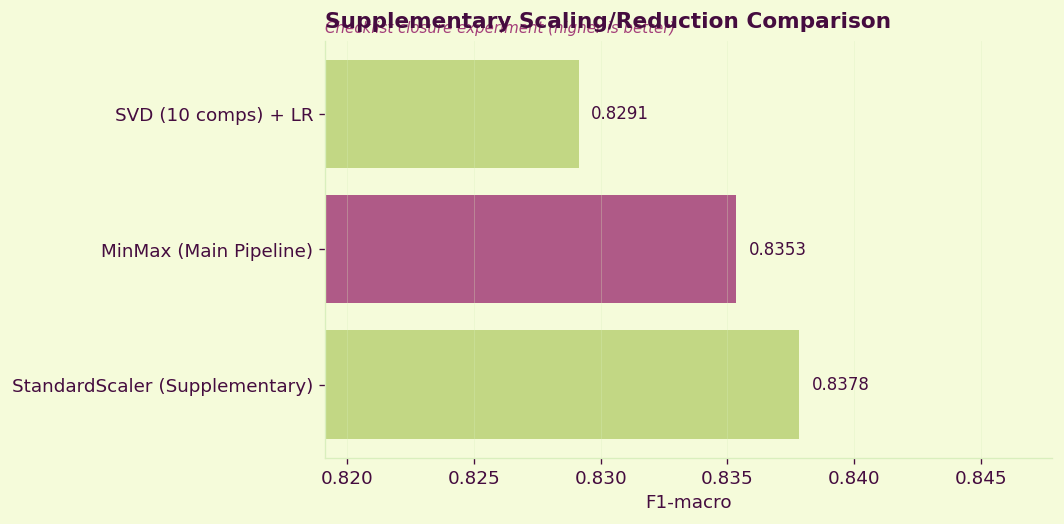

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD

supp_results = {}

# 1) Aggregation example
agg_cols = [c for c in ['Academic Pressure', 'Financial Stress', 'CGPA', 'Work/Study Hours'] if c in df_clean.columns]
if agg_cols and 'Gender' in df_clean.columns:
    agg_df = (
        df_clean.groupby(['Gender', 'Depression'])[agg_cols]
        .mean()
        .round(2)
        .reset_index()
    )
    display(agg_df.style.set_caption('Aggregation Example: Mean Features by Gender x Depression'))

# 2) StandardScaler supplementary comparison (vs current MinMax setup)
try:
    num_idx = list(range(min(6, X_train.shape[1])))
    scaler_std = StandardScaler()
    X_train_std = X_train.copy()
    X_test_std = X_test.copy()
    X_train_std[:, num_idx] = scaler_std.fit_transform(X_train[:, num_idx])
    X_test_std[:, num_idx] = scaler_std.transform(X_test[:, num_idx])

    lr_std = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    lr_std.fit(X_train_std, y_train)
    y_pred_std = lr_std.predict(X_test_std)
    f1_std = f1_score(y_test, y_pred_std, average='macro')
    f1_minmax = f1_score(y_test, y_pred, average='macro')

    supp_results['MinMax (Main Pipeline)'] = f1_minmax
    supp_results['StandardScaler (Supplementary)'] = f1_std

    print(f'StandardScaler supplementary F1-macro: {f1_std:.4f}')
    print(f'Current MinMax pipeline F1-macro    : {f1_minmax:.4f}')
except Exception as e:
    print('StandardScaler supplementary block skipped:', e)

# 3) SVD supplementary check
try:
    n_comp = min(10, X_train.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
    X_train_svd = svd.fit_transform(X_train)
    X_test_svd = svd.transform(X_test)

    lr_svd = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    lr_svd.fit(X_train_svd, y_train)
    y_pred_svd = lr_svd.predict(X_test_svd)
    f1_svd = f1_score(y_test, y_pred_svd, average='macro')

    supp_results[f'SVD ({n_comp} comps) + LR'] = f1_svd

    print(f'TruncatedSVD ({n_comp} comps) + LR F1-macro: {f1_svd:.4f}')
    print(f'Explained variance ratio sum: {svd.explained_variance_ratio_.sum():.4f}')
except Exception as e:
    print('SVD supplementary block skipped:', e)

# 4) Visual summary chart
if supp_results:
    supp_df = pd.DataFrame({'Approach': list(supp_results.keys()), 'F1_macro': list(supp_results.values())})
    supp_df = supp_df.sort_values('F1_macro', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    fig.patch.set_facecolor(THEME['bg'])

    colors = [THEME['accent'] if 'Main Pipeline' in a else THEME['primary'] for a in supp_df['Approach']]
    bars = ax.barh(supp_df['Approach'], supp_df['F1_macro'], color=colors, alpha=0.85)

    for b in bars:
        ax.text(b.get_width() + 0.0005, b.get_y() + b.get_height()/2, f"{b.get_width():.4f}", va='center', fontsize=10)

    ax.set_xlabel('F1-macro')
    ax.set_xlim(max(0.75, supp_df['F1_macro'].min() - 0.01), min(1.0, supp_df['F1_macro'].max() + 0.01))
    styled_ax(ax, 'Supplementary Scaling/Reduction Comparison', 'Checklist closure experiment (higher is better)')
    ax.grid(axis='x', alpha=0.35)
    ax.grid(axis='y', alpha=0)

    plt.tight_layout()
    plt.show()

--- 
## 9b. Reproducibility and Environment Capture

These artifacts document the runtime, package versions, seeds, saved model bundle, and versioning limitations for checklist review.


In [ ]:
import platform, sys, subprocess

packages_to_capture = [
    'numpy', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn',
    'xgboost', 'lightgbm', 'imbalanced-learn', 'shap', 'mlflow',
    'optuna', 'lime', 'gradio'
]

version_rows = []
for pkg in packages_to_capture:
    try:
        mod_name = 'sklearn' if pkg == 'scikit-learn' else ('imblearn' if pkg == 'imbalanced-learn' else pkg.replace('-', '_'))
        mod = __import__(mod_name)
        version_rows.append((pkg, getattr(mod, '__version__', 'installed')))
    except Exception:
        version_rows.append((pkg, 'not installed / optional'))

env_df = pd.DataFrame(version_rows, columns=['package', 'version'])
env_meta = pd.DataFrame([
    ('python', sys.version.split()[0]),
    ('platform', platform.platform()),
    ('random_state', RANDOM_STATE),
    ('model_bundle', f'{MODELS_DIR}/student_depression_pipeline_bundle.pkl'),
    ('github_versioning', 'Not available inside this submitted notebook; code/model artifacts are saved locally.'),
], columns=['item', 'value'])

display(env_meta.style.set_caption('Environment Metadata'))
display(env_df.style.set_caption('Package Versions'))

req_path = f'{REPORTS_DIR}/requirements_checklist.txt'
with open(req_path, 'w') as f:
    for pkg, ver in version_rows:
        if ver != 'not installed / optional':
            f.write(f'{pkg}=={ver}\n')
print(f'Requirements snapshot saved to {req_path}')


---
## 11. Final Results and Checklist Evidence Matrix

This final block maps project outputs to checklist expectations and demonstrates traceability.

**Decision Note:** Methods not used in the core pipeline are either added as supplementary experiments or explicitly justified.

In [ ]:
checklist_rows = [
    # Data Quality Assessment
    ('Data Cleaning', 'Missing Value', 'Used', 'Financial Stress null rows identified and dropped.'),
    ('Data Cleaning', 'Noisy Data', 'Used', "Rare ambiguous 'Others' categories removed; invalid values audited."),
    ('Data Cleaning', 'Inconsistent Data', 'Used', 'CGPA=0 treated as invalid/inconsistent and removed.'),
    ('Data Cleaning', 'Outliers value', 'Used', 'Age and CGPA domain checks documented.'),
    ('Dimensionality Reduction', 'PCA', 'Supplementary', 'PCA variance diagnostic and 2D EDA projection added.'),
    ('Dimensionality Reduction', 'CHI Squared', 'Supplementary', 'SelectKBest chi-square ranking added.'),
    ('Dimensionality Reduction', 'Recursive Feature Elimination', 'Used', 'RFE selects 15 model-ready features.'),
    ('Dimensionality Reduction', 'SVD', 'Supplementary', 'TruncatedSVD + LR comparison added.'),
    ('Feature Engineering', 'Decompose Categorical Attributes', 'Used', 'One-hot encoding and binary mapping.'),
    ('Feature Engineering', 'Deal with Date', 'N/A', 'Dataset has no date/time column.'),
    ('Feature Engineering', 'Normalize / Standardize', 'Used', 'MinMax main pipeline; StandardScaler supplementary comparison.'),
    ('Feature Engineering', 'Linear combinations', 'Used', 'Academic Pressure x Sleep Duration interaction.'),
    ('Feature Engineering', 'Combining / Splitting Features', 'Used', 'Interaction feature plus selected transformed feature set.'),
    ('Sampling Data', 'Systematic Sampling', 'N/A', 'Not appropriate for supervised tabular split; stratified sampling used.'),
    ('Sampling Data', 'Random Sampling', 'Supplementary', 'Train/test split and seed sensitivity use random seeds with stratification.'),
    ('Sampling Data', 'Stratified sampling', 'Used', 'train_test_split(..., stratify=y) and StratifiedKFold.'),
    ('Sampling Data', 'Progressive sampling', 'Supplementary', 'Fractional training-size sanity check added.'),
    ('Sampling Data', 'Cluster Sampling', 'N/A', 'No natural cluster sampling unit in this dataset.'),
    ('Sampling Data', 'Weighted Sampling', 'N/A', 'Class weights/resampling are more suitable for target imbalance.'),
    ('Data Transformation', 'Min-max normalization', 'Used', 'ColumnTransformer applies MinMaxScaler to numeric features.'),
    ('Data Transformation', 'Attribute Selection', 'Used', 'RFE and chi-square ranking.'),
    ('Data Transformation', 'Aggregation', 'Supplementary', 'Gender x Depression groupby summary.'),
    ('Data Transformation', 'One-Hot Encoding', 'Used', 'Gender, Dietary Habits, Degree encoded.'),
    ('Imbalanced Data', 'Downsampling Majority Class', 'Supplementary', 'RandomUnderSampler comparison.'),
    ('Imbalanced Data', 'Upsampling Minority Class', 'Supplementary', 'RandomOverSampler comparison.'),
    ('Imbalanced Data', 'Ensembling Different Resampled Datasets', 'N/A', 'Compared resampling methods; did not ensemble resampled datasets.'),
    ('Imbalanced Data', 'Balanced Class Weight', 'Used', "class_weight='balanced' and boosting imbalance parameters."),
    ('Imbalanced Data', 'Generate Synthetic Data', 'Supplementary', 'SMOTE comparison.'),
    ('Imbalanced Data', 'K-fold Cross Validation', 'Used', 'Stratified 5-fold CV.'),
    ('Text Preprocessing', 'Tokenization / normalization / stemming / PHI / language handling', 'N/A', 'Structured tabular dataset, not raw text/NLP corpus.'),
    ('Representation Learning', 'Autoencoders / contrastive / pretrained extractors / entity embeddings', 'N/A', 'Out of scope for this tabular baseline; PCA/SVD/RFE used instead.'),
    ('Representation Learning', 'UMAP/t-SNE/manifold learning', 'N/A', 'PCA projection used for multivariate visualization; UMAP/t-SNE optional and not required.'),

    # EDA
    ('EDA', 'Univariate Analysis', 'Used', 'Histograms/KDE and numeric distributions.'),
    ('EDA', 'Bivariate Analysis', 'Used', 'Correlation, point-biserial ranking, target relationships.'),
    ('EDA', 'Multivariate Analysis', 'Used', 'PCA projection of model-ready features.'),
    ('EDA', 'Target-conditional distributions', 'Used', 'Class-wise numeric and categorical plots.'),
    ('EDA', 'Missingness pattern visualization', 'Used', 'missingno matrix added.'),
    ('EDA', 'Train-vs-test distribution comparison', 'Used', 'KS and categorical percentage drift checks added.'),
    ('EDA', 'Embedding-space visualization', 'Supplementary', 'PCA feature-space visualization used as tabular embedding projection.'),

    # Modeling
    ('Model Algorithms', 'Clustering Techniques', 'N/A', 'Project is supervised binary classification.'),
    ('Model Algorithms', 'Regression Techniques', 'Used', 'Logistic Regression classifier.'),
    ('Model Algorithms', 'Neural Networks', 'Used', 'MLPClassifier added to main model comparison.'),
    ('Model Algorithms', 'Decision Trees', 'Used', 'Decision Tree classifier.'),
    ('Model Algorithms', 'Ensemble Methods', 'Used', 'Random Forest, XGBoost, LightGBM.'),
    ('Model Algorithms', 'SVM', 'Used', 'Linear SVM added to main model comparison.'),
    ('Model Algorithms', 'Gradient Boosting specifics', 'Used', 'XGBoost and LightGBM.'),
    ('Model Algorithms', 'Sequence / Transformer / LLM / RAG / GNN / Time-series', 'N/A', 'Not aligned with structured tabular classification objective.'),
    ('Model Algorithms', 'Bayesian models / Gaussian Processes', 'N/A', 'Not needed for this dataset; discriminative classifiers prioritized.'),
    ('Model Algorithms', 'Semi-supervised / pseudo-labeling', 'N/A', 'Labels are available for supervised learning.'),

    # Metrics and validation
    ('Metric', 'Accuracy', 'Used', 'CV and held-out accuracy reported.'),
    ('Metric', 'F1-score-Recall', 'Used', 'F1-macro and recall reported.'),
    ('Metric', 'ROC-AUC', 'Used', 'ROC-AUC and ROC curve reported.'),
    ('Metric', 'Optimization algorithm', 'Used', 'Logistic/MLP optimization and GridSearchCV documented.'),
    ('Metric', 'Learning rate', 'Supplementary', 'MLP tuning grid includes learning_rate_init if MLP is best.'),
    ('Metric', 'Train-test split ratio', 'Used', '80/20 split.'),
    ('Metric', 'Cost or Loss function', 'Used', 'Classifier losses implicit; evaluation optimizes F1-macro.'),
    ('Hyperparameter', 'Grid / Random search', 'Used', 'GridSearchCV.'),
    ('Hyperparameter', 'Bayesian optimization', 'Used', 'Optuna TPE optimization added.'),
    ('Hyperparameter', 'Multi-fidelity / Population-based training', 'N/A', 'Too heavy for course notebook; GridSearch/Optuna sufficient.'),
    ('Validation Strategy', 'K-fold / Stratified K-fold', 'Used', 'StratifiedKFold.'),
    ('Validation Strategy', 'Out-of-fold prediction storage', 'Used', 'OOF predictions saved to reports/oof_predictions.csv.'),
    ('Validation Strategy', 'Seed sensitivity analysis', 'Used', 'Five-seed stability table added.'),
    ('Validation Strategy', 'Statistical significance testing', 'Used', 'Paired t-test, McNemar, bootstrap CI.'),
    ('Validation Strategy', 'Subgroup / fairness evaluation', 'Used', 'Gender and Academic Pressure subgroup checks.'),

    # Bonus, explainability, reproducibility
    ('Ensembling', 'Bagging / Boosting', 'Used', 'Random Forest, XGBoost, LightGBM.'),
    ('Ensembling', 'Stacking / Blending', 'N/A', 'OOF predictions stored, but stacking not used because single tuned LR was stable.'),
    ('Ensembling', 'Snapshot / multi-seed ensembling', 'N/A', 'Seed sensitivity measured; final model kept simple.'),
    ('Ensembling', 'Pseudo-labeling', 'N/A', 'No unlabeled pool.'),
    ('Explainability', 'Feature importance', 'Used', 'Permutation importance and model-based/SHAP evidence.'),
    ('Explainability', 'SHAP', 'Used', 'SHAP summary and top drivers.'),
    ('Explainability', 'LIME', 'Supplementary', 'Attempted when installed; SHAP/permutation used as robust fallback.'),
    ('Explainability', 'Attention / Integrated Gradients', 'N/A', 'No deep attention model selected.'),
    ('Explainability', 'Counterfactual explanations', 'N/A', 'Out of scope; error analysis and SHAP prioritized.'),
    ('Explainability', 'Error analysis', 'Used', 'FP/FN analysis and threshold tuning.'),
    ('Reproducibility & MLOps', 'Random-seed control', 'Used', 'RANDOM_STATE plus seed sensitivity.'),
    ('Reproducibility & MLOps', 'Experiment tracking', 'Used', 'MLflow logging with CSV fallback.'),
    ('Reproducibility & MLOps', 'Data / code / model versioning', 'Supplementary', 'Model bundle and artifacts saved; external GitHub not available in notebook.'),
    ('Reproducibility & MLOps', 'Environment capture', 'Used', 'Package versions and requirements snapshot saved.'),
    ('Reproducibility & MLOps', 'Model card documentation', 'Used', 'Intended use, not intended use, ethics, limitations.'),
    ('Presentation', 'Interactive demo', 'Used', 'Gradio demo.'),
]

checklist_evidence_df = pd.DataFrame(checklist_rows, columns=['Phase', 'Checklist Item', 'Status', 'Evidence / Justification'])

status_order = pd.CategoricalDtype(['Used', 'Supplementary', 'N/A', 'Missing'], ordered=True)
checklist_evidence_df['Status'] = checklist_evidence_df['Status'].astype(status_order)
checklist_evidence_df = checklist_evidence_df.sort_values(['Status', 'Phase', 'Checklist Item']).reset_index(drop=True)

status_summary = checklist_evidence_df['Status'].value_counts().reindex(status_order.categories, fill_value=0).reset_index()
status_summary.columns = ['Status', 'Count']

display(status_summary.style.set_caption('Checklist Coverage Summary'))
display(
    checklist_evidence_df.style
    .set_caption('Comprehensive SENG 352 Checklist Evidence Matrix')
    .set_properties(subset=['Evidence / Justification'], **{'text-align': 'left'})
)


In [49]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f7e3136d2d2563aebe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
